# ViT-Base with Lung Region Attention for Chest X-Ray Classification

This notebook implements a Vision Transformer (ViT-Base) based deep learning model for multi-class classification of chest X-ray images from the **COVID-19 Radiography Database**.

The dataset contains four classes:

- COVID
- Lung Opacity
- Normal
- Viral Pneumonia

The main objective is to investigate whether incorporating **lung-region attention** into a ViT-Base model can improve classification performance by encouraging the model to focus on relevant lung regions.

### Model Overview

The experiment uses:

- **ViT-Base/16** as the backbone
- Input image size: **224 × 224**
- Lung Region Attention module
- Attention-guided learning
- AdamW optimizer
- Cosine learning-rate scheduling
- Two-phase training strategy
- Explainability analysis using Grad-CAM

### Experimental Environment

This experiment is being executed locally using:

- Python
- PyTorch
- `timm`
- Jupyter Notebook
- VS Code
- NVIDIA GeForce RTX 2050 (4 GB VRAM)

The dataset is stored locally, and all model training, evaluation, checkpointing, and explainability analysis are performed in the local environment.

> **Note:** The RTX 2050 has 4 GB of VRAM, so the initial batch size is set to 8 to reduce the risk of CUDA out-of-memory errors.

## Environment check

In [2]:
import sys
import torch
import torchvision
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("ViT-Base Experiment Environment")
print("=" * 60)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("timm:", timm.__version__)

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:",
          f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print("Compute capability:",
          f"sm_{torch.cuda.get_device_capability(0)[0]}"
          f"{torch.cuda.get_device_capability(0)[1]}")

print("Device:", device)
print("=" * 60)

ViT-Base Experiment Environment
Python: 3.13.7
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
timm: 1.0.30
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 2050
GPU memory: 4.00 GB
Compute capability: sm_86
Device: cuda


## Dataset path and structure

In [3]:
from pathlib import Path
import os
import json
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF

from tqdm.auto import tqdm

import timm

DATA_DIR = Path(
    r"C:\Users\USER\Desktop\Dnn_1\COVID-19_Radiography_Dataset"
)

CLASSES = [
    "COVID",
    "Lung_Opacity",
    "Normal",
    "Viral Pneumonia",
]

print("Imports successful.")
print("Dataset:", DATA_DIR)
print("Classes:", CLASSES)

Imports successful.
Dataset: C:\Users\USER\Desktop\Dnn_1\COVID-19_Radiography_Dataset
Classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


## Imports

In [4]:
class Args:
    # Dataset
    data_dir = str(DATA_DIR)
    output_dir = "./runs/vit_base_lung_attention"

    # Model
    model_name = "vit_base_patch16_224"
    pretrained = True
    num_classes = 4
    img_size = 224

    # Local GPU
    batch_size = 8
    num_workers = 0

    # Training
    phase1_epochs = 15
    phase1_lr = 1e-3

    phase2_epochs = 40
    phase2_lr = 1e-5

    unfreeze_blocks = 2

    optimizer = "adamw"
    weight_decay = 1e-4
    scheduler = "cosine"
    patience = 5

    # Lung attention
    attention_reduction = 8
    gate_mode = "residual"

    # This will be selected after the lambda sweep
    lambda_att = 0.5

    # Reproducibility
    seed = 42


args = Args()

Path(args.output_dir).mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 60)
print("Experiment Configuration")
print("=" * 60)

print("Model:", args.model_name)
print("Pretrained:", args.pretrained)
print("Image size:", args.img_size)

print("\nHardware:")
print("Batch size:", args.batch_size)
print("Workers:", args.num_workers)

print("\nPhase 1:")
print("Epochs:", args.phase1_epochs)
print("Learning rate:", args.phase1_lr)

print("\nPhase 2:")
print("Epochs:", args.phase2_epochs)
print("Learning rate:", args.phase2_lr)
print("Unfreeze blocks:", args.unfreeze_blocks)

print("\nOptimization:")
print("Optimizer:", args.optimizer)
print("Weight decay:", args.weight_decay)
print("Scheduler:", args.scheduler)
print("Patience:", args.patience)

print("\nAttention:")
print("Reduction:", args.attention_reduction)
print("Gate mode:", args.gate_mode)
print("Initial lambda:", args.lambda_att)

print("\nSeed:", args.seed)
print("Output:", args.output_dir)

print("=" * 60)

Experiment Configuration
Model: vit_base_patch16_224
Pretrained: True
Image size: 224

Hardware:
Batch size: 8
Workers: 0

Phase 1:
Epochs: 15
Learning rate: 0.001

Phase 2:
Epochs: 40
Learning rate: 1e-05
Unfreeze blocks: 2

Optimization:
Optimizer: adamw
Weight decay: 0.0001
Scheduler: cosine
Patience: 5

Attention:
Reduction: 8
Gate mode: residual
Initial lambda: 0.5

Seed: 42
Output: ./runs/vit_base_lung_attention


## Experiment configuration

In [5]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(args.seed)

print("=" * 60)
print("Reproducibility")
print("=" * 60)
print("Seed:", args.seed)
print("CUDA deterministic:", torch.backends.cudnn.deterministic)
print("CUDA benchmark:", torch.backends.cudnn.benchmark)
print("=" * 60)

Reproducibility
Seed: 42
CUDA deterministic: True
CUDA benchmark: False


## Reproducibility

In [6]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Make results more reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(args.seed)

print("=" * 60)
print("Reproducibility Setup")
print("=" * 60)
print("Seed:", args.seed)
print("CUDA deterministic:", torch.backends.cudnn.deterministic)
print("CUDA benchmark:", torch.backends.cudnn.benchmark)
print("=" * 60)

Reproducibility Setup
Seed: 42
CUDA deterministic: True
CUDA benchmark: False


## Dataset structure verification

In [7]:
print("=" * 60)
print("Dataset Verification")
print("=" * 60)

assert DATA_DIR.exists(), f"Dataset not found: {DATA_DIR}"

total_images = 0
total_masks = 0

for class_name in CLASSES:
    class_dir = DATA_DIR / class_name
    image_dir = class_dir / "images"
    mask_dir = class_dir / "masks"

    assert class_dir.exists(), f"Missing class: {class_dir}"
    assert image_dir.exists(), f"Missing images folder: {image_dir}"
    assert mask_dir.exists(), f"Missing masks folder: {mask_dir}"

    image_paths = sorted(image_dir.glob("*.png"))
    mask_paths = sorted(mask_dir.glob("*.png"))

    image_names = {p.name for p in image_paths}
    mask_names = {p.name for p in mask_paths}

    missing_masks = image_names - mask_names
    extra_masks = mask_names - image_names

    print(
        f"{class_name:18s} | "
        f"images: {len(image_paths):5d} | "
        f"masks: {len(mask_paths):5d}"
    )

    assert not missing_masks, (
        f"{class_name}: missing masks: {len(missing_masks)}"
    )

    assert not extra_masks, (
        f"{class_name}: extra masks: {len(extra_masks)}"
    )

    total_images += len(image_paths)
    total_masks += len(mask_paths)

print("-" * 60)
print("Total images:", total_images)
print("Total masks:", total_masks)

assert total_images == total_masks
assert total_images > 0

print("All dataset checks passed.")
print("=" * 60)

Dataset Verification
COVID              | images:  3616 | masks:  3616
Lung_Opacity       | images:  6012 | masks:  6012
Normal             | images: 10192 | masks: 10192
Viral Pneumonia    | images:  1345 | masks:  1345
------------------------------------------------------------
Total images: 21165
Total masks: 21165
All dataset checks passed.


## Build the stratified train/validation/test split

In [8]:
from torchvision.datasets import ImageFolder

def is_image_file(path):
    path = Path(path)
    return (
        path.parent.name == "images"
        and path.suffix.lower() in {".png", ".jpg", ".jpeg"}
    )

base_dataset = ImageFolder(
    root=str(DATA_DIR),
    is_valid_file=is_image_file
)

targets = np.array(base_dataset.targets)
indices = np.arange(len(base_dataset))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=targets,
    random_state=args.seed
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=targets[temp_idx],
    random_state=args.seed
)

print("=" * 60)
print("Corrected Dataset Split")
print("=" * 60)

print("Total:", len(indices))
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

print("\nClass mapping:")
print(base_dataset.class_to_idx)

print("\nClass distribution:")

for class_idx, class_name in enumerate(base_dataset.classes):
    train_count = np.sum(targets[train_idx] == class_idx)
    val_count = np.sum(targets[val_idx] == class_idx)
    test_count = np.sum(targets[test_idx] == class_idx)

    print(
        f"{class_name:18s} | "
        f"train: {train_count:5d} | "
        f"val: {val_count:5d} | "
        f"test: {test_count:5d}"
    )

assert len(indices) == 21165
assert len(train_idx) == 14815
assert len(val_idx) == 3175
assert len(test_idx) == 3175

assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0

assert all(
    Path(path).parent.name == "images"
    for path, _ in base_dataset.samples
)

print("\nSplit checks passed.")
print("Only image files are included.")
print("=" * 60)

Corrected Dataset Split
Total: 21165
Train: 14815
Validation: 3175
Test: 3175

Class mapping:
{'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}

Class distribution:
COVID              | train:  2531 | val:   543 | test:   542
Lung_Opacity       | train:  4208 | val:   902 | test:   902
Normal             | train:  7134 | val:  1529 | test:  1529
Viral Pneumonia    | train:   942 | val:   201 | test:   202

Split checks passed.
Only image files are included.


## Joint image + mask transforms

In [9]:
class JointTransform:
    def __init__(self, img_size=224, train=False):
        self.img_size = img_size
        self.train = train
        self.color_jitter = transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2
        )

    def __call__(self, image, mask):
        image = TF.resize(
            image,
            [self.img_size, self.img_size],
            interpolation=InterpolationMode.BILINEAR
        )

        mask = TF.resize(
            mask,
            [self.img_size, self.img_size],
            interpolation=InterpolationMode.NEAREST
        )

        if self.train:
            image = TF.pad(
                image,
                padding=8,
                padding_mode="reflect"
            )

            mask = TF.pad(
                mask,
                padding=8,
                fill=0
            )

            i, j, h, w = transforms.RandomCrop.get_params(
                image,
                output_size=(self.img_size, self.img_size)
            )

            image = TF.crop(image, i, j, h, w)
            mask = TF.crop(mask, i, j, h, w)

            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            angle = random.uniform(-10, 10)

            image = TF.rotate(
                image,
                angle,
                interpolation=InterpolationMode.BILINEAR
            )

            mask = TF.rotate(
                mask,
                angle,
                interpolation=InterpolationMode.NEAREST
            )

            image = self.color_jitter(image)

        image = TF.to_grayscale(
            image,
            num_output_channels=3
        )

        image = TF.to_tensor(image)

        image = TF.normalize(
            image,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        mask = TF.to_grayscale(
            mask,
            num_output_channels=1
        )

        mask = TF.to_tensor(mask)

        mask = (mask > 0.5).float()

        return image, mask


train_transform = JointTransform(
    img_size=args.img_size,
    train=True
)

eval_transform = JointTransform(
    img_size=args.img_size,
    train=False
)

print("Transforms created.")
print("Train:", train_transform.train)
print("Validation/Test:", eval_transform.train)

Transforms created.
Train: True
Validation/Test: False


## Mask-paired dataset

In [10]:
class CXRWithMaskDataset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = int(self.indices[idx])

        image_path, label = self.base_dataset.samples[base_idx]

        image_path = Path(image_path)
        mask_path = image_path.parent.parent / "masks" / image_path.name

        image = Image.open(image_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        image, mask = self.transform(image, mask)

        return image, label, mask


train_dataset = CXRWithMaskDataset(
    base_dataset,
    train_idx,
    train_transform
)

val_dataset = CXRWithMaskDataset(
    base_dataset,
    val_idx,
    eval_transform
)

test_dataset = CXRWithMaskDataset(
    base_dataset,
    test_idx,
    eval_transform
)

print("=" * 60)
print("Dataset Objects")
print("=" * 60)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("=" * 60)

Dataset Objects
Train: 14815
Validation: 3175
Test: 3175


## DataLoaders

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=args.batch_size,
    shuffle=True,
    num_workers=args.num_workers,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=args.num_workers,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=args.num_workers,
    pin_memory=torch.cuda.is_available()
)

print("=" * 60)
print("DataLoaders")
print("=" * 60)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("Batch size:", args.batch_size)
print("Workers:", args.num_workers)
print("Pin memory:", torch.cuda.is_available())

print("=" * 60)

DataLoaders
Train batches: 1852
Validation batches: 397
Test batches: 397
Batch size: 8
Workers: 0
Pin memory: True


## Batch and mask sanity check

In [12]:
images, labels, masks = next(iter(train_loader))

print("=" * 60)
print("Batch Sanity Check")
print("=" * 60)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Masks shape:", masks.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)
print("Mask dtype:", masks.dtype)

print("Image device:", images.device)
print("Label device:", labels.device)
print("Mask device:", masks.device)

print("Image range:",
      float(images.min()),
      "to",
      float(images.max()))

print("Mask unique values:",
      torch.unique(masks).tolist())

print("Labels in batch:",
      torch.unique(labels).tolist())

assert images.shape == (
    args.batch_size,
    3,
    args.img_size,
    args.img_size
)

assert labels.shape == (args.batch_size,)

assert masks.shape == (
    args.batch_size,
    1,
    args.img_size,
    args.img_size
)

assert torch.isfinite(images).all()
assert torch.isfinite(masks).all()

assert set(torch.unique(masks).tolist()).issubset({0.0, 1.0})

assert labels.min() >= 0
assert labels.max() < args.num_classes

print("\nAll batch checks passed.")
print("=" * 60)

Batch Sanity Check
Images shape: torch.Size([8, 3, 224, 224])
Labels shape: torch.Size([8])
Masks shape: torch.Size([8, 1, 224, 224])
Image dtype: torch.float32
Label dtype: torch.int64
Mask dtype: torch.float32
Image device: cpu
Label device: cpu
Mask device: cpu
Image range: -2.1179039478302 to 2.640000104904175
Mask unique values: [0.0, 1.0]
Labels in batch: [0, 2]

All batch checks passed.


## Alignment Eyeball Check

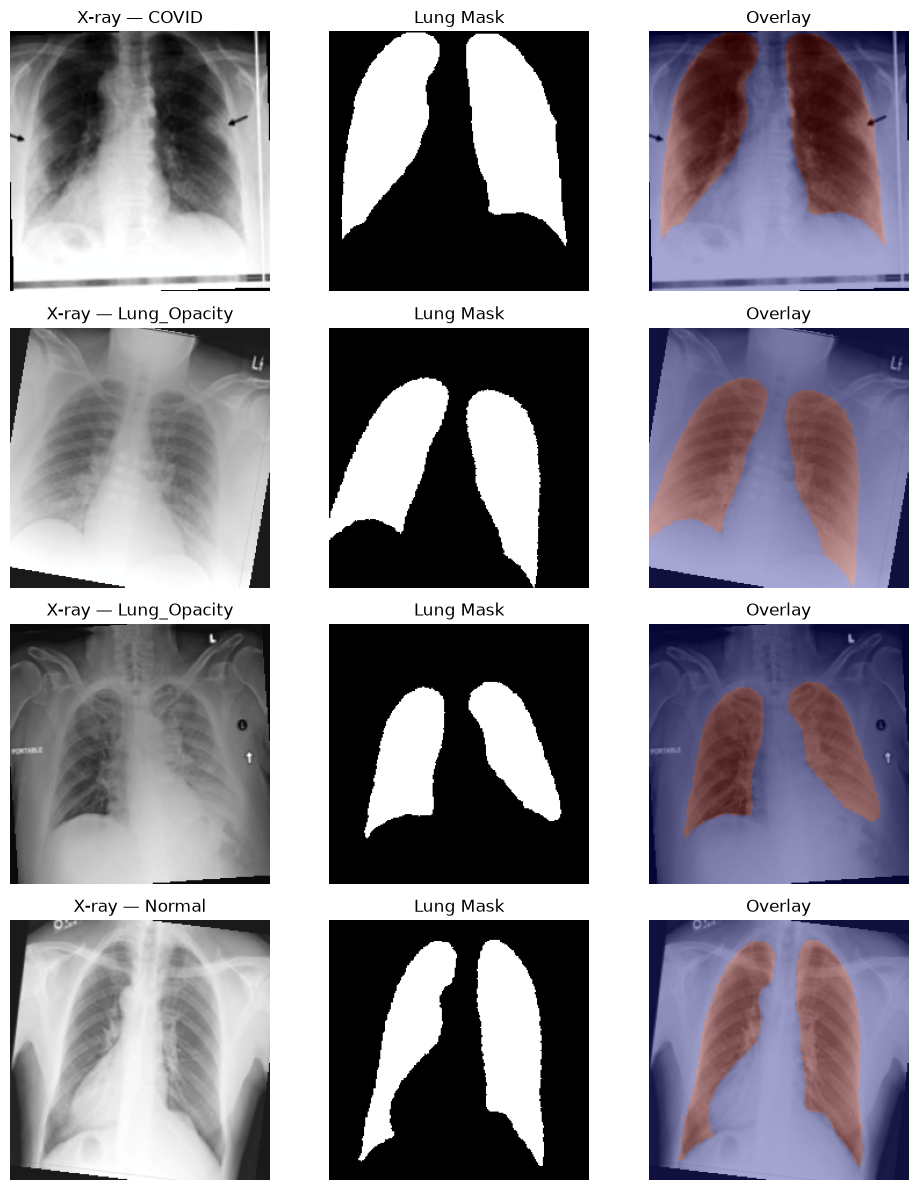

In [13]:
def show_alignment(dataset, indices_to_show=None):
    if indices_to_show is None:
        indices_to_show = [0, 1, 2, 3]

    fig, axes = plt.subplots(
        len(indices_to_show),
        3,
        figsize=(10, 3 * len(indices_to_show))
    )

    if len(indices_to_show) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices_to_show):
        image, label, mask = dataset[idx]

        image_display = image.permute(1, 2, 0).numpy()

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        image_display = image_display * std + mean
        image_display = np.clip(image_display, 0, 1)

        mask_display = mask.squeeze(0).numpy()

        axes[row, 0].imshow(image_display, cmap="gray")
        axes[row, 0].set_title(
            f"X-ray — {base_dataset.classes[label]}"
        )

        axes[row, 1].imshow(mask_display, cmap="gray")
        axes[row, 1].set_title("Lung Mask")

        axes[row, 2].imshow(image_display, cmap="gray")
        axes[row, 2].imshow(
            mask_display,
            cmap="jet",
            alpha=0.35
        )
        axes[row, 2].set_title("Overlay")

        for col in range(3):
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


show_alignment(train_dataset, [0, 100, 500, 1000])

In [14]:
vit = timm.create_model(
    args.model_name,
    pretrained=args.pretrained,
    num_classes=args.num_classes
)

vit = vit.to(device)

print("=" * 60)
print("ViT-Base Backbone")
print("=" * 60)
print("Model:", args.model_name)
print("Parameters:", sum(p.numel() for p in vit.parameters()))
print("Trainable:", sum(p.numel() for p in vit.parameters() if p.requires_grad))
print("Device:", device)
print("=" * 60)

ViT-Base Backbone
Model: vit_base_patch16_224
Parameters: 85801732
Trainable: 85801732
Device: cuda


## Lung Region Attention module

In [15]:
class LungRegionAttention(nn.Module):
    def __init__(
        self,
        in_channels,
        reduction=8,
        gate_mode="residual",
        init_bias=-6.0
    ):
        super().__init__()

        hidden = max(in_channels // reduction, 16)

        self.gate_mode = gate_mode

        self.conv1 = nn.Conv2d(
            in_channels,
            hidden,
            kernel_size=1,
            bias=True
        )

        self.act = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            hidden,
            1,
            kernel_size=1,
            bias=True
        )

        nn.init.kaiming_normal_(
            self.conv1.weight,
            nonlinearity="relu"
        )

        nn.init.zeros_(self.conv1.bias)
        nn.init.zeros_(self.conv2.weight)
        nn.init.constant_(self.conv2.bias, init_bias)

    def forward(self, feat):
        att_logits = self.conv2(
            self.act(self.conv1(feat))
        )

        att = torch.sigmoid(att_logits)

        if self.gate_mode == "residual":
            out = feat * (1.0 + att)

        elif self.gate_mode == "multiply":
            out = feat * att

        elif self.gate_mode == "none":
            out = feat

        else:
            raise ValueError(
                f"Unknown gate_mode: {self.gate_mode}"
            )

        return out, att, att_logits


print("LungRegionAttention created.")

test_attention = LungRegionAttention(
    in_channels=768,
    reduction=args.attention_reduction,
    gate_mode="residual"
)

print("Input channels:", 768)
print("Reduction:", args.attention_reduction)
print("Gate mode:", "residual")

LungRegionAttention created.
Input channels: 768
Reduction: 8
Gate mode: residual


## ViT-Base model

In [16]:
class ViTLungAttention(nn.Module):
    def __init__(
        self,
        num_classes=4,
        pretrained=True,
        use_attention=True,
        reduction=8,
        gate_mode="residual",
        drop_rate=0.0
    ):
        super().__init__()

        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=pretrained,
            num_classes=num_classes,
            global_pool="token",
            drop_rate=drop_rate
        )

        self.use_attention = use_attention

        if use_attention:
            self.attn = LungRegionAttention(
                in_channels=self.backbone.num_features,
                reduction=reduction,
                gate_mode=gate_mode
            )
        else:
            self.attn = None

    def forward(self, x):
        features = self.backbone.forward_features(x)

        patch_tokens = features[:, 1:]

        B, N, C = patch_tokens.shape

        H = W = int(N ** 0.5)

        assert H * W == N

        spatial_features = patch_tokens.transpose(1, 2)
        spatial_features = spatial_features.reshape(
            B, C, H, W
        )

        if self.attn is not None:
            spatial_features, att, att_logits = self.attn(
                spatial_features
            )
        else:
            att = None
            att_logits = None

        pooled = spatial_features.mean(dim=(2, 3))

        pooled = self.backbone.head_drop(pooled)

        logits = self.backbone.head(pooled)

        return logits, att, att_logits


print("Corrected ViT model class created.")

Corrected ViT model class created.


## Model forward + architecture checks

In [17]:
set_seed(args.seed)

model = ViTLungAttention(
    num_classes=args.num_classes,
    pretrained=args.pretrained,
    use_attention=True,
    reduction=args.attention_reduction,
    gate_mode="residual"
).to(device)

model.eval()

with torch.no_grad():
    sample_images, sample_labels, sample_masks = next(iter(val_loader))
    sample_images = sample_images.to(device)

    logits, att, att_logits = model(sample_images)

print("=" * 60)
print("ViT Model Check")
print("=" * 60)

print("Input shape:", sample_images.shape)
print("Logits shape:", logits.shape)
print("Attention shape:", att.shape)
print("Attention logits shape:", att_logits.shape)

print("Backbone features:", model.backbone.num_features)
print("Number of transformer blocks:", len(model.backbone.blocks))

print("Logits finite:", torch.isfinite(logits).all().item())
print("Attention finite:", torch.isfinite(att).all().item())
print("Attention logits finite:", torch.isfinite(att_logits).all().item())

assert logits.shape == (
    args.batch_size,
    args.num_classes
)

assert att.shape == (
    args.batch_size,
    1,
    14,
    14
)

assert att_logits.shape == (
    args.batch_size,
    1,
    14,
    14
)

assert torch.isfinite(logits).all()
assert torch.isfinite(att).all()
assert torch.isfinite(att_logits).all()

assert torch.all(att >= 0)
assert torch.all(att <= 1)

print("\nAll model checks passed.")
print("=" * 60)

ViT Model Check
Input shape: torch.Size([8, 3, 224, 224])
Logits shape: torch.Size([8, 4])
Attention shape: torch.Size([8, 1, 14, 14])
Attention logits shape: torch.Size([8, 1, 14, 14])
Backbone features: 768
Number of transformer blocks: 12
Logits finite: True
Attention finite: True
Attention logits finite: True

All model checks passed.


## A0 parity and attention-disabled checks

In [18]:
set_seed(args.seed)

model_a0 = ViTLungAttention(
    num_classes=args.num_classes,
    pretrained=True,
    use_attention=False,
    reduction=args.attention_reduction,
    gate_mode="residual"
).to(device)

model_none = ViTLungAttention(
    num_classes=args.num_classes,
    pretrained=True,
    use_attention=True,
    reduction=args.attention_reduction,
    gate_mode="none"
).to(device)

model_a0.eval()
model_none.eval()

model_none.backbone.load_state_dict(
    model_a0.backbone.state_dict()
)

with torch.no_grad():
    logits_a0, att_a0, att_logits_a0 = model_a0(
        sample_images
    )

    logits_none, att_none, att_logits_none = model_none(
        sample_images
    )

print("=" * 60)
print("A0 / Attention-Disabled Parity")
print("=" * 60)

print("A0 attention:", model_a0.attn)
print("None-mode attention:", model_none.attn is not None)

print("A0 logits shape:", logits_a0.shape)
print("None-mode logits shape:", logits_none.shape)

max_difference = (
    logits_a0 - logits_none
).abs().max().item()

print("Maximum logit difference:", max_difference)

assert model_a0.attn is None
assert att_a0 is None
assert att_logits_a0 is None

assert logits_a0.shape == (
    args.batch_size,
    args.num_classes
)

assert torch.equal(
    logits_a0,
    logits_none
)

assert att_none is not None
assert att_logits_none is not None

print("\nA0 parity checks passed.")
print("=" * 60)

A0 / Attention-Disabled Parity
A0 attention: None
None-mode attention: True
A0 logits shape: torch.Size([8, 4])
None-mode logits shape: torch.Size([8, 4])
Maximum logit difference: 0.0

A0 parity checks passed.


## Parameter and freeze checks

In [19]:
def count_parameters(model):
    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return total, trainable


def freeze_vit_backbone(model):
    for param in model.parameters():
        param.requires_grad = False

    for param in model.backbone.head.parameters():
        param.requires_grad = True

    if model.attn is not None:
        for param in model.attn.parameters():
            param.requires_grad = True


def unfreeze_vit_blocks(model, num_blocks=2):
    for param in model.parameters():
        param.requires_grad = False

    for param in model.backbone.head.parameters():
        param.requires_grad = True

    if model.attn is not None:
        for param in model.attn.parameters():
            param.requires_grad = True

    total_blocks = len(model.backbone.blocks)

    start_block = total_blocks - num_blocks

    for block_idx in range(start_block, total_blocks):
        for param in model.backbone.blocks[block_idx].parameters():
            param.requires_grad = True

    for param in model.backbone.norm.parameters():
        param.requires_grad = True


print("=" * 60)
print("Parameter / Freeze Checks")
print("=" * 60)

model_check = ViTLungAttention(
    num_classes=args.num_classes,
    pretrained=True,
    use_attention=True,
    reduction=args.attention_reduction,
    gate_mode="residual"
).to(device)

total_params, trainable_before = count_parameters(model_check)

print("Total parameters:", total_params)
print("Trainable initially:", trainable_before)

freeze_vit_backbone(model_check)

_, trainable_phase1 = count_parameters(model_check)

print("Trainable Phase 1:", trainable_phase1)

assert trainable_phase1 > 0
assert trainable_phase1 < total_params

unfreeze_vit_blocks(
    model_check,
    num_blocks=args.unfreeze_blocks
)

_, trainable_phase2 = count_parameters(model_check)

print("Trainable Phase 2:", trainable_phase2)

assert trainable_phase2 > trainable_phase1
assert trainable_phase2 < total_params

print("\nFreeze/unfreeze checks passed.")
print("=" * 60)

Parameter / Freeze Checks
Total parameters: 85875653
Trainable initially: 85875653
Trainable Phase 1: 76997
Trainable Phase 2: 14254277

Freeze/unfreeze checks passed.


## Attention loss + class weights

In [20]:
def attention_guidance_loss(
    att_logits,
    masks,
    target_mode="soft"
):
    if masks.ndim == 3:
        masks = masks.unsqueeze(1)

    masks = masks.float()

    target = F.adaptive_avg_pool2d(
        masks,
        att_logits.shape[-2:]
    )

    target = target.clamp(0.0, 1.0)

    if target_mode == "hard":
        target = (target > 0.5).float()

    return F.binary_cross_entropy_with_logits(
        att_logits,
        target
    )


train_targets = targets[train_idx]

class_counts = np.bincount(
    train_targets,
    minlength=args.num_classes
).astype(np.float32)

class_weights = (
    class_counts.sum()
    / (args.num_classes * class_counts)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

classification_criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("=" * 60)
print("Loss Configuration")
print("=" * 60)

print("Class counts:", class_counts.astype(int))
print("Class weights:", class_weights.detach().cpu().numpy())

print("Attention target:", "soft")
print("Initial lambda:", args.lambda_att)

print("=" * 60)

Loss Configuration
Class counts: [2531 4208 7134  942]
Class weights: [1.4633543  0.88016874 0.5191688  3.9317942 ]
Attention target: soft
Initial lambda: 0.5


## Metrics and evaluation function

In [21]:
def calculate_metrics(y_true, y_pred, y_prob):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred)
    }

    report = classification_report(
        y_true,
        y_pred,
        target_names=base_dataset.classes,
        output_dict=True,
        zero_division=0
    )

    metrics["macro_f1"] = report["macro avg"]["f1-score"]
    metrics["weighted_f1"] = report["weighted avg"]["f1-score"]

    try:
        metrics["macro_roc_auc"] = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        metrics["macro_roc_auc"] = float("nan")

    return metrics, report


@torch.no_grad()
def evaluate_model(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels, masks in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits, _, _ = model(images)

        loss = criterion(logits, labels)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs)

    metrics, report = calculate_metrics(
        y_true,
        y_pred,
        y_prob
    )

    metrics["loss"] = total_loss / total_samples

    return metrics, report, y_true, y_pred, y_prob


print("Evaluation functions created.")

Evaluation functions created.


## Training utilities

In [22]:
def create_optimizer(model, lr):
    trainable_params = [
        p for p in model.parameters()
        if p.requires_grad
    ]

    return torch.optim.AdamW(
        trainable_params,
        lr=lr,
        weight_decay=args.weight_decay
    )


def create_scheduler(optimizer, epochs):
    if args.scheduler == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs
        )

    return None


def train_one_epoch(
    model,
    loader,
    optimizer,
    scheduler,
    classification_criterion,
    lambda_att,
    device,
    scaler
):
    model.train()

    total_loss = 0.0
    total_cls_loss = 0.0
    total_att_loss = 0.0
    total_correct = 0
    total_samples = 0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels, masks in progress:
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=device.type == "cuda"
        ):
            logits, att, att_logits = model(images)

            cls_loss = classification_criterion(
                logits,
                labels
            )

            if (
                att_logits is not None
                and lambda_att > 0
            ):
                att_loss = attention_guidance_loss(
                    att_logits,
                    masks
                )
            else:
                att_loss = torch.zeros(
                    (),
                    device=device
                )

            loss = cls_loss + lambda_att * att_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_cls_loss += cls_loss.item() * batch_size
        total_att_loss += att_loss.item() * batch_size

        preds = logits.argmax(dim=1)

        total_correct += (
            preds == labels
        ).sum().item()

        total_samples += batch_size

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    if scheduler is not None:
        scheduler.step()

    return {
        "loss": total_loss / total_samples,
        "cls_loss": total_cls_loss / total_samples,
        "att_loss": total_att_loss / total_samples,
        "accuracy": total_correct / total_samples
    }


def train_phase(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    lambda_att,
    phase_name
):
    optimizer = create_optimizer(
        model,
        lr
    )

    scheduler = create_scheduler(
        optimizer,
        epochs
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=device.type == "cuda"
    )

    history = []

    best_f1 = -np.inf
    best_state = copy.deepcopy(
        model.state_dict()
    )

    patience_counter = 0

    for epoch in range(1, epochs + 1):

        print(
            f"\n{phase_name} | "
            f"Epoch {epoch}/{epochs}"
        )

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            classification_criterion=classification_criterion,
            lambda_att=lambda_att,
            device=device,
            scaler=scaler
        )

        val_metrics, _, _, _, _ = evaluate_model(
            model=model,
            loader=val_loader,
            criterion=classification_criterion,
            device=device
        )

        row = {
            "epoch": epoch,
            "phase": phase_name,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_metrics["loss"],
            "train_cls_loss": train_metrics["cls_loss"],
            "train_att_loss": train_metrics["att_loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "val_macro_roc_auc": val_metrics["macro_roc_auc"]
        }

        history.append(row)

        print(
            f"Train loss: {row['train_loss']:.4f} | "
            f"Train acc: {row['train_accuracy']:.4f}"
        )

        print(
            f"Val loss: {row['val_loss']:.4f} | "
            f"Val acc: {row['val_accuracy']:.4f} | "
            f"Val macro-F1: {row['val_macro_f1']:.4f}"
        )

        if row["val_macro_f1"] > best_f1:
            best_f1 = row["val_macro_f1"]
            best_state = copy.deepcopy(
                model.state_dict()
            )
            patience_counter = 0

        else:
            patience_counter += 1

        if patience_counter >= args.patience:
            print(
                f"Early stopping at epoch {epoch}."
            )
            break

    model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


print("Training utilities created.")

Training utilities created.


## GPU forward/backward smoke test

In [23]:
set_seed(args.seed)

smoke_model = ViTLungAttention(
    num_classes=args.num_classes,
    pretrained=True,
    use_attention=True,
    reduction=args.attention_reduction,
    gate_mode="residual"
).to(device)

smoke_model.train()

smoke_optimizer = torch.optim.AdamW(
    smoke_model.parameters(),
    lr=1e-4,
    weight_decay=args.weight_decay
)

smoke_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=device.type == "cuda"
)

print("=" * 60)
print("GPU Smoke Test")
print("=" * 60)

for step, (images, labels, masks) in enumerate(train_loader):

    if step >= 2:
        break

    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)
    masks = masks.to(device, non_blocking=True)

    smoke_optimizer.zero_grad(set_to_none=True)

    with torch.amp.autocast(
        device_type="cuda",
        enabled=device.type == "cuda"
    ):
        logits, att, att_logits = smoke_model(images)

        cls_loss = classification_criterion(
            logits,
            labels
        )

        att_loss = attention_guidance_loss(
            att_logits,
            masks
        )

        loss = cls_loss + 0.3 * att_loss

    smoke_scaler.scale(loss).backward()
    smoke_scaler.step(smoke_optimizer)
    smoke_scaler.update()

    print(
        f"Step {step + 1}: "
        f"loss={loss.item():.4f}, "
        f"cls={cls_loss.item():.4f}, "
        f"att={att_loss.item():.4f}"
    )

if torch.cuda.is_available():
    print(
        "GPU memory allocated:",
        f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
    )

    print(
        "GPU memory reserved:",
        f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
    )

print("\nGPU smoke test passed.")
print("=" * 60)

del smoke_model
del smoke_optimizer
del smoke_scaler

torch.cuda.empty_cache()

GPU Smoke Test
Step 1: loss=2.6886, cls=2.3177, att=1.2363
Step 2: loss=2.5762, cls=2.1124, att=1.5460
GPU memory allocated: 2.27 GB
GPU memory reserved: 2.89 GB

GPU smoke test passed.


## Attention overfit test

In [24]:
overfit_transform = JointTransform(
    img_size=args.img_size,
    train=False
)

overfit_dataset = CXRWithMaskDataset(
    base_dataset,
    train_idx[:32],
    overfit_transform
)

overfit_loader = DataLoader(
    overfit_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

set_seed(args.seed)

overfit_model = ViTLungAttention(
    num_classes=args.num_classes,
    pretrained=True,
    use_attention=True,
    reduction=args.attention_reduction,
    gate_mode="residual"
).to(device)

overfit_optimizer = torch.optim.AdamW(
    overfit_model.parameters(),
    lr=1e-4,
    weight_decay=0.0
)

overfit_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=device.type == "cuda"
)

overfit_model.train()

print("=" * 60)
print("32-Sample Overfit Test")
print("=" * 60)

initial_loss = None
final_loss = None

for step in range(100):

    images, labels, masks = next(
        iter(overfit_loader)
    )

    images = images.to(device)
    labels = labels.to(device)
    masks = masks.to(device)

    overfit_optimizer.zero_grad(
        set_to_none=True
    )

    with torch.amp.autocast(
        device_type="cuda",
        enabled=device.type == "cuda"
    ):
        logits, att, att_logits = overfit_model(
            images
        )

        cls_loss = classification_criterion(
            logits,
            labels
        )

        att_loss = attention_guidance_loss(
            att_logits,
            masks
        )

        loss = cls_loss + 0.3 * att_loss

    if initial_loss is None:
        initial_loss = loss.item()

    overfit_scaler.scale(loss).backward()
    overfit_scaler.step(overfit_optimizer)
    overfit_scaler.update()

    final_loss = loss.item()

    if (step + 1) % 20 == 0:
        print(
            f"Step {step + 1:3d}/100 | "
            f"loss={loss.item():.4f} | "
            f"cls={cls_loss.item():.4f} | "
            f"att={att_loss.item():.4f}"
        )

print("-" * 60)
print("Initial loss:", f"{initial_loss:.4f}")
print("Final loss:", f"{final_loss:.4f}")

assert np.isfinite(final_loss)
assert final_loss < initial_loss

print("\nOverfit test passed.")
print("=" * 60)

del overfit_model
del overfit_optimizer
del overfit_scaler

torch.cuda.empty_cache()

32-Sample Overfit Test
Step  20/100 | loss=1.1766 | cls=0.8012 | att=1.2513
Step  40/100 | loss=0.6797 | cls=0.3412 | att=1.1286
Step  60/100 | loss=0.2056 | cls=0.0045 | att=0.6702
Step  80/100 | loss=0.0867 | cls=0.0001 | att=0.2884
Step 100/100 | loss=0.0682 | cls=0.0000 | att=0.2271
------------------------------------------------------------
Initial loss: 3.0829
Final loss: 0.0682

Overfit test passed.


## Attention metric utilities

In [25]:
@torch.no_grad()
def attention_metrics(att, masks, threshold=0.5):
    if att is None:
        return {}

    if masks.ndim == 3:
        masks = masks.unsqueeze(1)

    masks = masks.float()

    masks_resized = F.interpolate(
        masks,
        size=att.shape[-2:],
        mode="nearest"
    )

    att = att.float().clamp(0.0, 1.0)

    inside = (
        att * masks_resized
    ).sum(dim=(1, 2, 3))

    outside = (
        att * (1.0 - masks_resized)
    ).sum(dim=(1, 2, 3))

    total = att.sum(
        dim=(1, 2, 3)
    ).clamp_min(1e-8)

    ilar = inside / total

    att_binary = att >= threshold

    mask_binary = masks_resized >= 0.5

    intersection = (
        att_binary & mask_binary
    ).sum(dim=(1, 2, 3)).float()

    union = (
        att_binary | mask_binary
    ).sum(dim=(1, 2, 3)).float()

    pred_area = att_binary.sum(
        dim=(1, 2, 3)
    ).float()

    mask_area = mask_binary.sum(
        dim=(1, 2, 3)
    ).float()

    iou = intersection / union.clamp_min(1.0)

    dice = (
        2.0 * intersection
        / (pred_area + mask_area).clamp_min(1.0)
    )

    background_attention = (
        outside / total
    )

    return {
        "ilar": ilar.mean().item(),
        "iou": iou.mean().item(),
        "dice": dice.mean().item(),
        "background_attention": background_attention.mean().item()
    }


print("Attention metric utilities created.")

Attention metric utilities created.


## Attention metric sanity check

In [26]:
model = ViTLungAttention(
    num_classes=args.num_classes,
    pretrained=True,
    use_attention=True,
    reduction=args.attention_reduction,
    gate_mode="residual"
).to(device)

model.eval()

images, labels, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits, att, att_logits = model(images)

metrics = attention_metrics(att, masks)

print("=" * 60)
print("Attention Metric Sanity Check")
print("=" * 60)

print("Attention shape:", tuple(att.shape))
print("Mask shape:", tuple(masks.shape))

for name, value in metrics.items():
    print(f"{name:22s}: {value:.4f}")

assert np.isfinite(list(metrics.values())).all()
assert 0.0 <= metrics["ilar"] <= 1.0
assert 0.0 <= metrics["iou"] <= 1.0
assert 0.0 <= metrics["dice"] <= 1.0
assert 0.0 <= metrics["background_attention"] <= 1.0

print("\nAttention metrics passed.")

del model
torch.cuda.empty_cache()

Attention Metric Sanity Check
Attention shape: (8, 1, 14, 14)
Mask shape: (8, 1, 224, 224)
ilar                  : 0.2449
iou                   : 0.0000
dice                  : 0.0000
background_attention  : 0.7551

Attention metrics passed.


## Final parameter and freeze audit

In [27]:
model = ViTLungAttention(
    num_classes=args.num_classes,
    pretrained=True,
    use_attention=True,
    reduction=args.attention_reduction,
    gate_mode="residual"
).to(device)

total_params, trainable_params = count_parameters(model)

print("=" * 60)
print("Parameter Audit")
print("=" * 60)

print(f"Total parameters:     {total_params:,}")
print(f"Initial trainable:    {trainable_params:,}")

freeze_vit_backbone(model)

_, phase1_trainable = count_parameters(model)

print(f"Phase 1 trainable:    {phase1_trainable:,}")

unfreeze_vit_blocks(
    model,
    num_blocks=args.unfreeze_blocks
)

_, phase2_trainable = count_parameters(model)

print(f"Phase 2 trainable:    {phase2_trainable:,}")

expected_phase1 = (
    sum(p.numel() for p in model.backbone.head.parameters())
    + sum(p.numel() for p in model.attn.parameters())
)

assert phase1_trainable == expected_phase1

assert phase2_trainable > phase1_trainable

trainable_names = [
    name for name, p in model.named_parameters()
    if p.requires_grad
]

assert any("blocks.10" in name for name in trainable_names)
assert any("blocks.11" in name for name in trainable_names)
assert any(name.startswith("backbone.norm") for name in trainable_names)

print("\nPhase 1/Phase 2 checks passed.")

del model
torch.cuda.empty_cache()

Parameter Audit
Total parameters:     85,875,653
Initial trainable:    85,875,653
Phase 1 trainable:    76,997
Phase 2 trainable:    14,254,277

Phase 1/Phase 2 checks passed.


## A0 parameter parity

In [28]:
a0_model = ViTLungAttention(
    num_classes=args.num_classes,
    pretrained=True,
    use_attention=False
).to(device)

plain_model = timm.create_model(
    args.model_name,
    pretrained=False,
    num_classes=args.num_classes,
    global_pool="token"
).to(device)

a0_total, _ = count_parameters(a0_model)
plain_total, _ = count_parameters(plain_model)

print("=" * 60)
print("A0 Parameter Parity")
print("=" * 60)

print(f"A0 parameters:        {a0_total:,}")
print(f"Plain ViT parameters: {plain_total:,}")
print(f"Difference:            {a0_total - plain_total:,}")

assert a0_total == plain_total

a0_state = a0_model.backbone.state_dict()
plain_state = plain_model.state_dict()

missing = []
unexpected = []

for key in a0_state:
    if key in plain_state:
        if a0_state[key].shape != plain_state[key].shape:
            missing.append(key)
    else:
        unexpected.append(key)

print("Shape mismatches:", len(missing))
print("Missing keys:", len(unexpected))

assert len(missing) == 0
assert len(unexpected) == 0

print("\nA0 parameter parity passed.")

del a0_model
del plain_model
torch.cuda.empty_cache()

A0 Parameter Parity
A0 parameters:        85,801,732
Plain ViT parameters: 85,801,732
Difference:            0
Shape mismatches: 0
Missing keys: 0

A0 parameter parity passed.


## Lambda sweep: setup, output folders and save helpers

Run this cell once before the sweep cells. Output layout (same style as T18):

```
runs/vit_base_lung_attention/
  sweep/
    lam_0.0/  phase1_frozen_history.json  phase2_finetune_history.json  result.json
    lam_0.1/  ...
    tuning_summary.csv
    selected_config.json
  figures/lambda_sweep.png
```

Rule used for file types: per-epoch histories, per-config results and selected config are **JSON**; the one-row-per-config summary table is **CSV**; plots are **PNG**.

In [73]:
import gc
import json
import math
import time
from pathlib import Path

from sklearn.metrics import f1_score, roc_auc_score

OUT_ROOT = Path(args.output_dir)
SWEEP_ROOT = OUT_ROOT / "sweep"
FIG_DIR = OUT_ROOT / "figures"

for d in (SWEEP_ROOT, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)


def _clean(obj):
    """Make an object strictly JSON-safe: numpy -> python, NaN/Inf -> None."""
    if isinstance(obj, dict):
        return {str(k): _clean(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_clean(v) for v in obj]
    if isinstance(obj, np.generic):
        obj = obj.item()
    if isinstance(obj, float) and not math.isfinite(obj):
        return None
    return obj


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(_clean(obj), f, indent=2)


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


print("Sweep root :", SWEEP_ROOT.resolve())
print("Figure dir :", FIG_DIR.resolve())

Sweep root : C:\Users\USER\Desktop\Dnn_1\runs\vit_base_lung_attention\sweep
Figure dir : C:\Users\USER\Desktop\Dnn_1\runs\vit_base_lung_attention\figures


## Lambda sweep function

Fixes compared with the previous version:

- validation now runs under `torch.no_grad()` (before, it built a full autograd graph on every val batch: slow and memory hungry on a 4 GB GPU)
- `f1_score` is imported
- the attention loss is always computed and logged (for `lam_0.0` it is logged but not optimised), so the `att=` column is meaningful for every lambda
- the logged `lr` is the lr actually used in that epoch
- tqdm progress bar per epoch, and optional `max_train_batches` / `max_val_batches` for a quick smoke test
- each phase history is written to JSON when the phase finishes

In [74]:
def _forward_losses(model, images, labels, masks, lambda_att):
    """One forward pass -> logits, att map, cls loss, att loss, total loss."""
    with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
        logits, att, att_logits = model(images)
        cls_loss = classification_criterion(logits, labels)

        if att_logits is not None:
            att_loss = attention_guidance_loss(att_logits.float(), masks)
        else:
            att_loss = torch.zeros((), device=images.device)

        # lambda = 0 -> attention loss is logged only, never optimised
        loss = cls_loss + lambda_att * att_loss if lambda_att > 0 else cls_loss

    return logits, att, cls_loss, att_loss, loss


def train_sweep_phase(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    lambda_att,
    phase_name,
    out_dir,
    max_train_batches=None,
    max_val_batches=None,
):
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=args.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    n_train_b = min(len(train_loader), max_train_batches or len(train_loader))
    n_val_b = min(len(val_loader), max_val_batches or len(val_loader))

    history = []

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        epoch_lr = optimizer.param_groups[0]["lr"]

        # ---------------- train ----------------
        model.train()
        tr_tot = tr_cls = tr_att = 0.0
        tr_correct = tr_n = 0

        for step, (images, labels, masks) in enumerate(
            tqdm(train_loader, total=n_train_b, leave=False,
                 desc=f"{phase_name} {epoch}/{epochs} train")
        ):
            if step >= n_train_b:
                break

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits, att, cls_loss, att_loss, loss = _forward_losses(
                model, images, labels, masks, lambda_att
            )

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            bs = labels.size(0)
            tr_tot += loss.item() * bs
            tr_cls += cls_loss.item() * bs
            tr_att += att_loss.item() * bs
            tr_correct += (logits.argmax(1) == labels).sum().item()
            tr_n += bs

        scheduler.step()

        # ---------------- validation ----------------
        model.eval()
        va_tot = va_cls = va_att = 0.0
        va_correct = va_n = 0
        y_true, y_pred, y_prob = [], [], []
        ilar_vals, dice_vals = [], []

        with torch.no_grad():
            for step, (images, labels, masks) in enumerate(
                tqdm(val_loader, total=n_val_b, leave=False,
                     desc=f"{phase_name} {epoch}/{epochs} val")
            ):
                if step >= n_val_b:
                    break

                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)

                logits, att, cls_loss, att_loss, loss = _forward_losses(
                    model, images, labels, masks, lambda_att
                )

                bs = labels.size(0)
                va_tot += loss.item() * bs
                va_cls += cls_loss.item() * bs
                va_att += att_loss.item() * bs
                va_correct += (logits.argmax(1) == labels).sum().item()
                va_n += bs

                probs = torch.softmax(logits.float(), dim=1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(probs.argmax(1).cpu().numpy())
                y_prob.append(probs.cpu())

                if att is not None:
                    m = attention_metrics(att, masks)
                    ilar_vals.append(m["ilar"])
                    dice_vals.append(m["dice"])

        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        y_prob = torch.cat(y_prob).numpy()

        val_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

        try:
            val_auc = roc_auc_score(
                y_true, y_prob, multi_class="ovr", average="macro",
                labels=list(range(args.num_classes)),
            )
        except ValueError:
            val_auc = float("nan")

        row = {
            "epoch": epoch,
            "phase": phase_name,
            "lr": epoch_lr,
            "train_loss": tr_tot / tr_n,
            "train_cls_loss": tr_cls / tr_n,
            "train_att_loss": tr_att / tr_n,
            "train_accuracy": tr_correct / tr_n,
            "val_loss": va_tot / va_n,
            "val_cls_loss": va_cls / va_n,
            "val_att_loss": va_att / va_n,
            "val_accuracy": va_correct / va_n,
            "val_macro_f1": val_f1,
            "val_macro_roc_auc": val_auc,
            "val_ilar": float(np.mean(ilar_vals)) if ilar_vals else float("nan"),
            "val_dice": float(np.mean(dice_vals)) if dice_vals else float("nan"),
            "epoch_seconds": time.time() - t0,
        }
        history.append(row)

        print(
            f"[{phase_name}] epoch {epoch}/{epochs} "
            f"train_loss={row['train_loss']:.4f} "
            f"(cls={row['train_cls_loss']:.4f}, att={row['train_att_loss']:.4f}) "
            f"train_acc={row['train_accuracy']:.4f} | "
            f"val_loss={row['val_loss']:.4f} "
            f"(cls={row['val_cls_loss']:.4f}, att={row['val_att_loss']:.4f}) "
            f"val_acc={row['val_accuracy']:.4f} "
            f"val_f1={row['val_macro_f1']:.4f} "
            f"val_ilar={row['val_ilar']:.4f} "
            f"[{row['epoch_seconds']:.0f}s]"
        )

    save_json(history, Path(out_dir) / f"{phase_name}_history.json")
    return history

## Run one lambda value

Each lambda writes `result.json` when it finishes. If VS Code / the kernel stops halfway, run the sweep cell again: finished lambdas are skipped, unfinished ones restart from scratch.

In [75]:
assert args.optimizer == "adamw" and args.scheduler == "cosine", \
    "train_sweep_phase is hard-coded to AdamW + cosine"


def best_row_by_val_loss(history):
    return min(history, key=lambda r: r["val_loss"])


def run_sweep_config(
    cfg,
    phase1_epochs,
    phase2_epochs,
    root=SWEEP_ROOT,
    max_train_batches=None,
    max_val_batches=None,
    force=False,
):
    cfg_dir = Path(root) / cfg["name"]
    cfg_dir.mkdir(parents=True, exist_ok=True)
    result_path = cfg_dir / "result.json"

    if result_path.exists() and not force:
        print(f"SKIP {cfg['name']}: result.json already exists")
        return load_json(result_path)

    print("\n" + "=" * 90)
    print(f"SWEEP: {cfg['name']} | {cfg}")
    print("=" * 90)

    t0 = time.time()
    set_seed(args.seed)

    model = ViTLungAttention(
        num_classes=args.num_classes,
        pretrained=args.pretrained,
        use_attention=True,
        reduction=args.attention_reduction,
        gate_mode=cfg["gate_mode"],
        drop_rate=0.0,
    ).to(device)

    # Phase 1: frozen backbone
    freeze_vit_backbone(model)
    h1 = train_sweep_phase(
        model, train_loader, val_loader, phase1_epochs,
        cfg["phase1_lr"], cfg["lambda_att"], "phase1_frozen", cfg_dir,
        max_train_batches, max_val_batches,
    )

    # Phase 2: unfreeze last blocks
    unfreeze_vit_blocks(model, num_blocks=args.unfreeze_blocks)
    h2 = train_sweep_phase(
        model, train_loader, val_loader, phase2_epochs,
        cfg["phase2_lr"], cfg["lambda_att"], "phase2_finetune", cfg_dir,
        max_train_batches, max_val_batches,
    )

    best = best_row_by_val_loss(h2)

    result = {
        **cfg,
        "phase1_epochs": phase1_epochs,
        "phase2_epochs": phase2_epochs,
        "best_epoch": best["epoch"],
        "best_val_loss": best["val_loss"],
        "best_val_cls_loss": best["val_cls_loss"],
        "val_acc_at_best_loss": best["val_accuracy"],
        "val_macro_f1_at_best": best["val_macro_f1"],
        "val_ilar_at_best": best["val_ilar"],
        "val_dice_at_best": best["val_dice"],
        "elapsed_minutes": (time.time() - t0) / 60,
    }
    save_json(result, result_path)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

## Lambda sweep smoke run

In [76]:
LAMBDA_VALUES = [0.0, 0.1, 0.3, 0.5, 1.0]
TUNE_PHASE1_EPOCHS = 4
TUNE_PHASE2_EPOCHS = 6

BASE_CFG = {
    "phase1_lr": args.phase1_lr,
    "phase2_lr": args.phase2_lr,
    "weight_decay": args.weight_decay,
    "optimizer": args.optimizer,
    "scheduler": args.scheduler,
    "gate_mode": args.gate_mode,
}

TUNING_CONFIGS = [
    {"name": f"lam_{lam}", "lambda_att": lam, **BASE_CFG}
    for lam in LAMBDA_VALUES
]

print("=" * 60)
print("Lambda Sweep Configuration")
print("=" * 60)
print(pd.DataFrame(TUNING_CONFIGS).to_string(index=False))
print(f"\nSchedule: {TUNE_PHASE1_EPOCHS} frozen + {TUNE_PHASE2_EPOCHS} fine-tune epochs per lambda")
print("Selection uses the validation set only (test set is not touched).")

Lambda Sweep Configuration
   name  lambda_att  phase1_lr  phase2_lr  weight_decay optimizer scheduler gate_mode
lam_0.0         0.0      0.001    0.00001        0.0001     adamw    cosine  residual
lam_0.1         0.1      0.001    0.00001        0.0001     adamw    cosine  residual
lam_0.3         0.3      0.001    0.00001        0.0001     adamw    cosine  residual
lam_0.5         0.5      0.001    0.00001        0.0001     adamw    cosine  residual
lam_1.0         1.0      0.001    0.00001        0.0001     adamw    cosine  residual

Schedule: 4 frozen + 6 fine-tune epochs per lambda
Selection uses the validation set only (test set is not touched).


## Lambda sweep smoke test

Uses a few batches only (about a minute). Writes to `sweep_smoke/`, not to the real sweep folder.

In [77]:
smoke_cfg = {"name": "smoke_lam_0.3", "lambda_att": 0.3, **BASE_CFG}

smoke = run_sweep_config(
    smoke_cfg,
    phase1_epochs=1,
    phase2_epochs=1,
    root=OUT_ROOT / "sweep_smoke",
    max_train_batches=30,
    max_val_batches=10,
    force=True,
)

assert math.isfinite(smoke["best_val_loss"]), "val loss is not finite"
assert 0.0 <= smoke["val_ilar_at_best"] <= 1.0, "ILAR out of range"

print("\n" + "=" * 60)
print("LAMBDA SMOKE TEST RESULT")
print("=" * 60)
for k, v in smoke.items():
    print(f"{k:24s}: {v:.4f}" if isinstance(v, float) else f"{k:24s}: {v}")
print("\nSmoke test passed.")


SWEEP: smoke_lam_0.3 | {'name': 'smoke_lam_0.3', 'lambda_att': 0.3, 'phase1_lr': 0.001, 'phase2_lr': 1e-05, 'weight_decay': 0.0001, 'optimizer': 'adamw', 'scheduler': 'cosine', 'gate_mode': 'residual'}


phase1_frozen 1/1 train:   0%|          | 0/30 [00:00<?, ?it/s]

phase1_frozen 1/1 val:   0%|          | 0/10 [00:00<?, ?it/s]

[phase1_frozen] epoch 1/1 train_loss=1.8904 (cls=1.6566, att=0.7796) train_acc=0.3292 | val_loss=1.6735 (cls=1.5533, att=0.4008) val_acc=0.1750 val_f1=0.2272 val_ilar=0.4876 [38s]


phase2_finetune 1/1 train:   0%|          | 0/30 [00:00<?, ?it/s]

phase2_finetune 1/1 val:   0%|          | 0/10 [00:00<?, ?it/s]

[phase2_finetune] epoch 1/1 train_loss=1.2424 (cls=1.1229, att=0.3982) train_acc=0.5375 | val_loss=1.0207 (cls=0.9126, att=0.3605) val_acc=0.6250 val_f1=0.6567 val_ilar=0.4794 [49s]

LAMBDA SMOKE TEST RESULT
name                    : smoke_lam_0.3
lambda_att              : 0.3000
phase1_lr               : 0.0010
phase2_lr               : 0.0000
weight_decay            : 0.0001
optimizer               : adamw
scheduler               : cosine
gate_mode               : residual
phase1_epochs           : 1
phase2_epochs           : 1
best_epoch              : 1
best_val_loss           : 1.0207
best_val_cls_loss       : 0.9126
val_acc_at_best_loss    : 0.6250
val_macro_f1_at_best    : 0.6567
val_ilar_at_best        : 0.4794
val_dice_at_best        : 0.5254
elapsed_minutes         : 1.4983

Smoke test passed.


## Run the lambda sweep

Resumable: re-run this cell after an interruption and finished lambdas are skipped.

In [78]:
sweep_start = time.time()

for cfg in TUNING_CONFIGS:
    run_sweep_config(cfg, TUNE_PHASE1_EPOCHS, TUNE_PHASE2_EPOCHS)

print(f"\nSweep finished in {(time.time() - sweep_start) / 60:.1f} min (this session)")


SWEEP: lam_0.0 | {'name': 'lam_0.0', 'lambda_att': 0.0, 'phase1_lr': 0.001, 'phase2_lr': 1e-05, 'weight_decay': 0.0001, 'optimizer': 'adamw', 'scheduler': 'cosine', 'gate_mode': 'residual'}


phase1_frozen 1/4 train:   0%|          | 0/1852 [00:00<?, ?it/s]

phase1_frozen 1/4 val:   0%|          | 0/397 [00:00<?, ?it/s]

[phase1_frozen] epoch 1/4 train_loss=0.5664 (cls=0.5664, att=4.3613) train_acc=0.7622 | val_loss=0.3926 (cls=0.3926, att=4.7112) val_acc=0.8564 val_f1=0.8537 val_ilar=0.2137 [254s]


phase1_frozen 2/4 train:   0%|          | 0/1852 [00:00<?, ?it/s]

...

phase2_finetune 5/6 val:   0%|          | 0/397 [00:00<?, ?it/s]

[phase2_finetune] epoch 5/6 train_loss=0.3478 (cls=0.1915, att=0.1563) train_acc=0.9172 | val_loss=0.3706 (cls=0.2160, att=0.1546) val_acc=0.9143 val_f1=0.9251 val_ilar=0.7389 [418s]


phase2_finetune 6/6 train:   0%|          | 0/1852 [00:00<?, ?it/s]

phase2_finetune 6/6 val:   0%|          | 0/397 [00:00<?, ?it/s]

[phase2_finetune] epoch 6/6 train_loss=0.3364 (cls=0.1801, att=0.1562) train_acc=0.9209 | val_loss=0.3556 (cls=0.2011, att=0.1545) val_acc=0.9197 val_f1=0.9276 val_ilar=0.7406 [424s]

Sweep finished in 894.7 min (this session)


## Run the lambda sweep

Resumable: re-run this cell after an interruption and finished lambdas are skipped.

In [79]:
sweep_start = time.time()

for cfg in TUNING_CONFIGS:
    run_sweep_config(cfg, TUNE_PHASE1_EPOCHS, TUNE_PHASE2_EPOCHS)

print(f"\nSweep finished in {(time.time() - sweep_start) / 60:.1f} min (this session)")

SKIP lam_0.0: result.json already exists
SKIP lam_0.1: result.json already exists
SKIP lam_0.3: result.json already exists
SKIP lam_0.5: result.json already exists
SKIP lam_1.0: result.json already exists

Sweep finished in 0.0 min (this session)


## Tuning summary (CSV)

In [80]:
rows, missing = [], []
for cfg in TUNING_CONFIGS:
    p = SWEEP_ROOT / cfg["name"] / "result.json"
    (rows if p.exists() else missing).append(load_json(p) if p.exists() else cfg["name"])

assert not missing, f"Sweep not finished for: {missing}"

SUMMARY_COLS = [
    "name", "lambda_att", "phase1_lr", "phase2_lr", "weight_decay",
    "optimizer", "scheduler", "gate_mode",
    "best_epoch", "best_val_loss", "best_val_cls_loss",
    "val_acc_at_best_loss", "val_macro_f1_at_best",
    "val_ilar_at_best", "val_dice_at_best", "elapsed_minutes",
]

tuning_df = pd.DataFrame(rows)[SUMMARY_COLS]
tuning_df.to_csv(SWEEP_ROOT / "tuning_summary.csv", index=False)

print("Saved:", SWEEP_ROOT / "tuning_summary.csv")
tuning_df

Saved: runs\vit_base_lung_attention\sweep\tuning_summary.csv


,name,lambda_att,phase1_lr,phase2_lr,weight_decay,optimizer,scheduler,gate_mode,best_epoch,best_val_loss,best_val_cls_loss,val_acc_at_best_loss,val_macro_f1_at_best,val_ilar_at_best,val_dice_at_best,elapsed_minutes
0,lam_0.0,0.0,0.001,0.00001,0.0001,adamw,cosine,residual,6,0.201371,0.201371,0.919685,0.928262,0.199439,0.000000,716.115905
1,lam_0.1,0.1,0.001,0.00001,0.0001,adamw,cosine,residual,6,0.220173,0.201072,0.918740,0.926581,0.705190,0.746432,42.866720
2,lam_0.3,0.3,0.001,0.00001,0.0001,adamw,cosine,residual,6,0.251591,0.201631,0.919055,0.927144,0.728512,0.761717,43.107045
3,lam_0.5,0.5,0.001,0.00001,0.0001,adamw,cosine,residual,6,0.282128,0.201748,0.919055,0.927526,0.733942,0.767314,39.778924
4,lam_1.0,1.0,0.001,0.00001,0.0001,adamw,cosine,residual,6,0.355595,0.201063,0.919685,0.927612,0.740623,0.769904,52.819143


## Lambda sweep plot

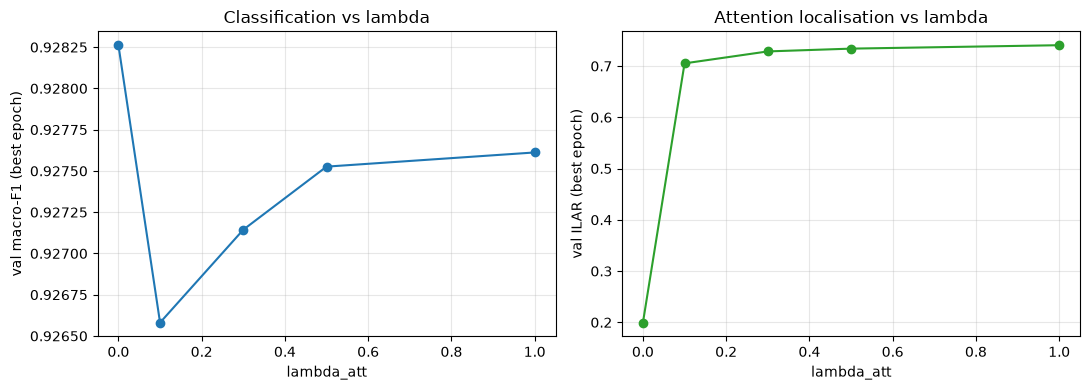

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(tuning_df["lambda_att"], tuning_df["val_macro_f1_at_best"], marker="o")
axes[0].set_xlabel("lambda_att")
axes[0].set_ylabel("val macro-F1 (best epoch)")
axes[0].set_title("Classification vs lambda")
axes[0].grid(alpha=0.3)

axes[1].plot(tuning_df["lambda_att"], tuning_df["val_ilar_at_best"], marker="o", color="tab:green")
axes[1].set_xlabel("lambda_att")
axes[1].set_ylabel("val ILAR (best epoch)")
axes[1].set_title("Attention localisation vs lambda")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "lambda_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## Select lambda

Among the lambdas whose validation macro-F1 is within 0.005 of the `lam_0.0` reference, pick the one with the highest validation ILAR. Ties are broken by higher macro-F1, then lower lambda.

In [82]:
F1_TOLERANCE = 0.005

ref = tuning_df[tuning_df["name"] == "lam_0.0"].iloc[0]
ref_f1 = float(ref["val_macro_f1_at_best"])

candidates = tuning_df[tuning_df["val_macro_f1_at_best"] >= ref_f1 - F1_TOLERANCE].copy()
candidates = candidates.sort_values(
    ["val_ilar_at_best", "val_macro_f1_at_best", "lambda_att"],
    ascending=[False, False, True],
)
chosen = candidates.iloc[0]

selected_config = {
    "name": str(chosen["name"]),
    "lambda_att": float(chosen["lambda_att"]),
    "phase1_lr": float(chosen["phase1_lr"]),
    "phase2_lr": float(chosen["phase2_lr"]),
    "weight_decay": float(chosen["weight_decay"]),
    "optimizer": str(chosen["optimizer"]),
    "scheduler": str(chosen["scheduler"]),
    "gate_mode": str(chosen["gate_mode"]),
    "attention_reduction": args.attention_reduction,
    "attention_target_mode": "soft",
    "unfreeze_blocks": args.unfreeze_blocks,
    "seed": args.seed,
    "selection_rule": f"highest val ILAR among lambdas with val macro-F1 >= lam_0.0 - {F1_TOLERANCE}",
    "reference_name": "lam_0.0",
    "reference_val_macro_f1": ref_f1,
    "selected_val_macro_f1": float(chosen["val_macro_f1_at_best"]),
    "selected_val_ilar": float(chosen["val_ilar_at_best"]),
    "sweep_schedule": {"phase1_epochs": TUNE_PHASE1_EPOCHS, "phase2_epochs": TUNE_PHASE2_EPOCHS},
}
save_json(selected_config, SWEEP_ROOT / "selected_config.json")

args.lambda_att = selected_config["lambda_att"]

print("Candidates within tolerance:")
print(candidates[["name", "val_macro_f1_at_best", "val_ilar_at_best"]].to_string(index=False))
print("\nSelected lambda:", args.lambda_att)
print("Saved:", SWEEP_ROOT / "selected_config.json")

Candidates within tolerance:
   name  val_macro_f1_at_best  val_ilar_at_best
lam_1.0              0.927612          0.740623
lam_0.5              0.927526          0.733942
lam_0.3              0.927144          0.728512
lam_0.1              0.926581          0.705190
lam_0.0              0.928262          0.199439

Selected lambda: 1.0
Saved: runs\vit_base_lung_attention\sweep\selected_config.json


In [83]:
args.lambda_att = load_json(SWEEP_ROOT / "selected_config.json")["lambda_att"]
print("lambda_att =", args.lambda_att)

lambda_att = 1.0


## Seven-arm training: model update (adds CBAM)

Replaces the `ViTLungAttention` class with a version that has an `attention="lung" | "cbam"` switch. Default is `"lung"`, so nothing else changes. CBAM is never mask-supervised (its `att_logits` is `None`), but its spatial map is still returned so ILAR / Dice can be measured.

In [84]:
class CBAM2d(nn.Module):
    """Standard CBAM on a (B, C, H, W) map: channel attention, then spatial attention.
    Returns (out, spatial_att, None). No att_logits -> can never be mask-supervised."""

    def __init__(self, in_channels, reduction=8, kernel_size=7):
        super().__init__()
        hidden = max(in_channels // reduction, 16)
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, in_channels),
        )
        self.spatial = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2)

    def forward(self, feat):
        ch = torch.sigmoid(
            self.mlp(feat.mean(dim=(2, 3))) + self.mlp(feat.amax(dim=(2, 3)))
        )[:, :, None, None]
        feat = feat * ch

        pooled = torch.cat(
            [feat.mean(dim=1, keepdim=True), feat.amax(dim=1, keepdim=True)], dim=1
        )
        att = torch.sigmoid(self.spatial(pooled))
        return feat * att, att, None


class ViTLungAttention(nn.Module):
    def __init__(
        self,
        num_classes=4,
        pretrained=True,
        use_attention=True,
        reduction=8,
        gate_mode="residual",
        drop_rate=0.0,
        attention="lung",
    ):
        super().__init__()

        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=pretrained,
            num_classes=num_classes,
            global_pool="token",
            drop_rate=drop_rate,
        )

        self.use_attention = use_attention

        if not use_attention:
            self.attn = None
        elif attention == "lung":
            self.attn = LungRegionAttention(
                in_channels=self.backbone.num_features,
                reduction=reduction,
                gate_mode=gate_mode,
            )
        elif attention == "cbam":
            self.attn = CBAM2d(self.backbone.num_features, reduction=reduction)
        else:
            raise ValueError(f"Unknown attention: {attention}")

    def forward(self, x):
        features = self.backbone.forward_features(x)
        patch_tokens = features[:, 1:]

        B, N, C = patch_tokens.shape
        H = W = int(N ** 0.5)
        assert H * W == N

        spatial = patch_tokens.transpose(1, 2).reshape(B, C, H, W)

        if self.attn is not None:
            spatial, att, att_logits = self.attn(spatial)
        else:
            att, att_logits = None, None

        pooled = self.backbone.head_drop(spatial.mean(dim=(2, 3)))
        logits = self.backbone.head(pooled)

        return logits, att, att_logits


print("ViTLungAttention updated (attention = 'lung' | 'cbam').")

ViTLungAttention updated (attention = 'lung' | 'cbam').


## Seven-arm training: setup and train / evaluate helpers

Per arm, files are written to `runs/vit_base_lung_attention/seven_arm/<arm>/`:

| File | Format |
|---|---|
| `arm_config.json`, `arm_result.json` | JSON |
| `phase1_frozen_history.json`, `phase2_finetune_history.json` | JSON |
| `test_results_frozen.json`, `test_results_finetuned.json` (metrics, classification report, confusion matrix) | JSON |
| `confusion_matrix_*.csv`, `test_predictions_*.csv` (one row per test image) | CSV |
| `final_model.pt` | checkpoint |

Best epoch and early stopping use **validation macro-F1** (same as your earlier `train_phase`), because `val_loss` includes `lambda x att` and is not comparable across arms. The test set is only evaluated, never used for selection.

In [85]:
import copy
from sklearn.metrics import classification_report, confusion_matrix

ARMS_ROOT = OUT_ROOT / "seven_arm"
ARMS_ROOT.mkdir(parents=True, exist_ok=True)

LAMBDA_STAR = load_json(SWEEP_ROOT / "selected_config.json")["lambda_att"]
print("LAMBDA_STAR =", LAMBDA_STAR)


def _arm_forward_losses(model, images, labels, masks, lambda_att, target_mode):
    with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
        logits, att, att_logits = model(images)
        cls_loss = classification_criterion(logits, labels)

        if att_logits is not None:
            att_loss = attention_guidance_loss(
                att_logits.float(), masks, target_mode=target_mode
            )
        else:                                   # no attention / CBAM
            att_loss = torch.zeros((), device=images.device)

        supervised = lambda_att > 0 and att_logits is not None
        loss = cls_loss + lambda_att * att_loss if supervised else cls_loss

    return logits, att, cls_loss, att_loss, loss


@torch.no_grad()
def _run_eval(model, loader, lambda_att, target_mode, desc):
    model.eval()
    tot = cls_s = att_s = 0.0
    n = 0
    ys, ps, pr = [], [], []
    att_m = {"ilar": [], "iou": [], "dice": [], "background_attention": []}

    for images, labels, masks in tqdm(loader, leave=False, desc=desc):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits, att, cls_loss, att_loss, loss = _arm_forward_losses(
            model, images, labels, masks, lambda_att, target_mode
        )

        bs = labels.size(0)
        tot += loss.item() * bs
        cls_s += cls_loss.item() * bs
        att_s += att_loss.item() * bs
        n += bs

        probs = torch.softmax(logits.float(), dim=1)
        ys.append(labels.cpu().numpy())
        ps.append(probs.argmax(1).cpu().numpy())
        pr.append(probs.cpu().numpy())

        if att is not None:
            m = attention_metrics(att, masks)
            for k in att_m:
                att_m[k].append(m[k])

    y_true, y_pred, y_prob = np.concatenate(ys), np.concatenate(ps), np.concatenate(pr)

    try:
        auc = roc_auc_score(
            y_true, y_prob, multi_class="ovr", average="macro",
            labels=list(range(args.num_classes)),
        )
    except ValueError:
        auc = float("nan")

    out = {
        "loss": tot / n,
        "cls_loss": cls_s / n,
        "att_loss": att_s / n,
        "accuracy": float((y_true == y_pred).mean()),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "macro_roc_auc": float(auc),
    }
    for k, v in att_m.items():
        out[k] = float(np.mean(v)) if v else float("nan")

    return out, y_true, y_pred, y_prob


def train_arm_phase(model, epochs, lr, lambda_att, target_mode, phase_name, arm_name, arm_dir):
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=args.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    history = []
    best_f1 = -np.inf
    best_state = None                     # kept on CPU (4 GB GPU)
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        epoch_lr = optimizer.param_groups[0]["lr"]

        model.train()
        tr_tot = tr_cls = tr_att = 0.0
        tr_correct = tr_n = 0

        for images, labels, masks in tqdm(
            train_loader, leave=False, desc=f"{arm_name} {phase_name} {epoch}/{epochs}"
        ):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits, att, cls_loss, att_loss, loss = _arm_forward_losses(
                model, images, labels, masks, lambda_att, target_mode
            )
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            bs = labels.size(0)
            tr_tot += loss.item() * bs
            tr_cls += cls_loss.item() * bs
            tr_att += att_loss.item() * bs
            tr_correct += (logits.argmax(1) == labels).sum().item()
            tr_n += bs

        scheduler.step()

        val, _, _, _ = _run_eval(model, val_loader, lambda_att, target_mode, "val")

        is_best = val["macro_f1"] > best_f1
        if is_best:
            best_f1 = val["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        row = {
            "epoch": epoch,
            "phase": phase_name,
            "lr": epoch_lr,
            "train_loss": tr_tot / tr_n,
            "train_cls_loss": tr_cls / tr_n,
            "train_att_loss": tr_att / tr_n,
            "train_accuracy": tr_correct / tr_n,
            "val_loss": val["loss"],
            "val_cls_loss": val["cls_loss"],
            "val_att_loss": val["att_loss"],
            "val_accuracy": val["accuracy"],
            "val_macro_f1": val["macro_f1"],
            "val_weighted_f1": val["weighted_f1"],
            "val_macro_roc_auc": val["macro_roc_auc"],
            "val_ilar": val["ilar"],
            "val_dice": val["dice"],
            "is_best": bool(is_best),
            "epoch_seconds": time.time() - t0,
        }
        history.append(row)

        print(
            f"[{arm_name} | {phase_name}] epoch {epoch}/{epochs} "
            f"train_loss={row['train_loss']:.4f} "
            f"(cls={row['train_cls_loss']:.4f}, att={row['train_att_loss']:.4f}) "
            f"train_acc={row['train_accuracy']:.4f} | "
            f"val_loss={row['val_loss']:.4f} val_acc={row['val_accuracy']:.4f} "
            f"val_f1={row['val_macro_f1']:.4f} val_ilar={row['val_ilar']:.4f} "
            f"{'*best* ' if is_best else ''}[{row['epoch_seconds']:.0f}s]"
        )

        if bad_epochs >= args.patience:
            print(f"[{arm_name} | {phase_name}] early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)          # restore best-val-F1 weights
    save_json(history, Path(arm_dir) / f"{phase_name}_history.json")
    return history


def evaluate_arm(model, arm_name, arm_dir, tag, lambda_att, target_mode):
    out, y_true, y_pred, y_prob = _run_eval(
        model, test_loader, lambda_att, target_mode, f"{arm_name} test {tag}"
    )

    class_names = list(base_dataset.classes)
    report = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

    save_json(
        {"tag": tag, "n_test": int(len(y_true)), "class_names": class_names,
         "metrics": out, "classification_report": report,
         "confusion_matrix": cm.tolist()},
        Path(arm_dir) / f"test_results_{tag}.json",
    )
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        Path(arm_dir) / f"confusion_matrix_{tag}.csv"
    )

    ds = test_loader.dataset                    # test_loader has shuffle=False
    paths = [ds.base_dataset.samples[int(i)][0] for i in ds.indices]
    assert len(paths) == len(y_true)

    pred_df = pd.DataFrame(
        {"image_path": paths, "y_true": y_true, "y_pred": y_pred, "correct": y_true == y_pred}
    )
    for j, name in enumerate(class_names):
        pred_df[f"prob_{name}"] = y_prob[:, j]
    pred_df.to_csv(Path(arm_dir) / f"test_predictions_{tag}.csv", index=False)

    print(
        f"[{arm_name}] TEST {tag}: acc={out['accuracy']:.4f} "
        f"macro_f1={out['macro_f1']:.4f} auc={out['macro_roc_auc']:.4f} "
        f"ilar={out['ilar']:.4f} dice={out['dice']:.4f}"
    )
    return out

LAMBDA_STAR = 1.0


## Seven-arm training: one function, one call per arm

`run_arm` trains one arm end to end (frozen phase, fine-tune phase, test evaluation) and is resumable:

- a finished arm (`arm_result.json` exists) is skipped
- if the kernel stops during the fine-tune phase, the frozen-phase checkpoint is reused, so the ~1 h frozen phase is not repeated
- the seed is reset before the arm and again before phase 2, so a resumed run follows the same random stream as an uninterrupted one

In [86]:
def run_arm(
    arm_name,
    use_attention,
    attention,
    gate_mode,
    lambda_att,
    target_mode="soft",
    force=False,
):
    arm_dir = ARMS_ROOT / arm_name
    arm_dir.mkdir(parents=True, exist_ok=True)
    result_path = arm_dir / "arm_result.json"

    if result_path.exists() and not force:
        print(f"SKIP {arm_name}: arm_result.json already exists")
        return load_json(result_path)

    arm_cfg = {
        "arm": arm_name,
        "use_attention": use_attention,
        "attention": attention,
        "gate_mode": gate_mode,
        "lambda_att": lambda_att,
        "target_mode": target_mode,
        "phase1_epochs": args.phase1_epochs,
        "phase2_epochs": args.phase2_epochs,
        "phase1_lr": args.phase1_lr,
        "phase2_lr": args.phase2_lr,
        "weight_decay": args.weight_decay,
        "patience": args.patience,
        "unfreeze_blocks": args.unfreeze_blocks,
        "seed": args.seed,
    }
    save_json(arm_cfg, arm_dir / "arm_config.json")

    print("\n" + "=" * 90)
    print(f"ARM: {arm_name} | {arm_cfg}")
    print("=" * 90)

    t0 = time.time()
    set_seed(args.seed)

    model = ViTLungAttention(
        num_classes=args.num_classes,
        pretrained=args.pretrained,
        use_attention=use_attention,
        reduction=args.attention_reduction,
        gate_mode=gate_mode,
        drop_rate=0.0,
        attention=attention,
    ).to(device)

    # ---------------- Phase 1: frozen backbone ----------------
    p1_hist = arm_dir / "phase1_frozen_history.json"
    p1_ckpt = arm_dir / "phase1_frozen_best.pt"

    freeze_vit_backbone(model)

    if p1_hist.exists() and p1_ckpt.exists() and not force:
        print(f"[{arm_name}] phase 1 already finished -> loading checkpoint")
        model.load_state_dict(torch.load(p1_ckpt, map_location=device))
        h1 = load_json(p1_hist)
    else:
        h1 = train_arm_phase(
            model, args.phase1_epochs, args.phase1_lr, lambda_att, target_mode,
            "phase1_frozen", arm_name, arm_dir,
        )
        torch.save(model.state_dict(), p1_ckpt)

    test_frozen = evaluate_arm(model, arm_name, arm_dir, "frozen", lambda_att, target_mode)

    # ---------------- Phase 2: fine-tune last blocks ----------------
    set_seed(args.seed)
    unfreeze_vit_blocks(model, num_blocks=args.unfreeze_blocks)

    h2 = train_arm_phase(
        model, args.phase2_epochs, args.phase2_lr, lambda_att, target_mode,
        "phase2_finetune", arm_name, arm_dir,
    )
    torch.save(model.state_dict(), arm_dir / "final_model.pt")

    test_final = evaluate_arm(model, arm_name, arm_dir, "finetuned", lambda_att, target_mode)

    best = max(h2, key=lambda r: r["val_macro_f1"])
    total_params, trainable_phase2 = count_parameters(model)

    result = {
        **arm_cfg,
        "phase1_epochs_run": len(h1),
        "phase2_epochs_run": len(h2),
        "phase2_best_epoch": best["epoch"],
        "val_macro_f1_at_best": best["val_macro_f1"],
        "val_ilar_at_best": best["val_ilar"],
        "val_dice_at_best": best["val_dice"],
        "test_frozen_accuracy": test_frozen["accuracy"],
        "test_frozen_macro_f1": test_frozen["macro_f1"],
        "test_accuracy": test_final["accuracy"],
        "test_macro_f1": test_final["macro_f1"],
        "test_weighted_f1": test_final["weighted_f1"],
        "test_macro_roc_auc": test_final["macro_roc_auc"],
        "test_loss": test_final["cls_loss"],
        "test_ilar": test_final["ilar"],
        "test_iou": test_final["iou"],
        "test_dice": test_final["dice"],
        "test_background_attention": test_final["background_attention"],
        "total_parameters": total_params,
        "elapsed_minutes": (time.time() - t0) / 60,
    }
    save_json(result, result_path)

    p1_ckpt.unlink(missing_ok=True)            # arm finished: free ~340 MB

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

## A0_vanilla

Plain ViT-Base, no attention module (baseline).

In [87]:
A0_result = run_arm(
    "A0_vanilla",
    use_attention=False,
    attention="lung",
    gate_mode="residual",
    lambda_att=0.0,
)


ARM: A0_vanilla | {'arm': 'A0_vanilla', 'use_attention': False, 'attention': 'lung', 'gate_mode': 'residual', 'lambda_att': 0.0, 'target_mode': 'soft', 'phase1_epochs': 15, 'phase2_epochs': 40, 'phase1_lr': 0.001, 'phase2_lr': 1e-05, 'weight_decay': 0.0001, 'patience': 5, 'unfreeze_blocks': 2, 'seed': 42}


A0_vanilla phase1_frozen 1/15:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A0_vanilla | phase1_frozen] epoch 1/15 train_loss=0.5717 (cls=0.5717, att=0.0000) train_acc=0.7624 | val_loss=0.4083 val_acc=0.8510 val_f1=0.8515 val_ilar=nan *best* [216s]


A0_vanilla phase1_frozen 2/15:   0%|          | 0/1852 [00:00<?, ?it/s]

...

A0_vanilla phase2_finetune 10/40:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A0_vanilla | phase2_finetune] epoch 10/40 train_loss=0.1642 (cls=0.1642, att=0.0000) train_acc=0.9249 | val_loss=0.2226 val_acc=0.9203 val_f1=0.9284 val_ilar=nan [260s]
[A0_vanilla | phase2_finetune] early stopping at epoch 10


A0_vanilla test finetuned:   0%|          | 0/397 [00:00<?, ?it/s]

[A0_vanilla] TEST finetuned: acc=0.9235 macro_f1=0.9299 auc=0.9878 ilar=nan dice=nan


## A1_gate_only

Lung attention gate, no mask supervision (lambda = 0).

In [88]:
A1_result = run_arm(
    "A1_gate_only",
    use_attention=True,
    attention="lung",
    gate_mode="residual",
    lambda_att=0.0,
)


ARM: A1_gate_only | {'arm': 'A1_gate_only', 'use_attention': True, 'attention': 'lung', 'gate_mode': 'residual', 'lambda_att': 0.0, 'target_mode': 'soft', 'phase1_epochs': 15, 'phase2_epochs': 40, 'phase1_lr': 0.001, 'phase2_lr': 1e-05, 'weight_decay': 0.0001, 'patience': 5, 'unfreeze_blocks': 2, 'seed': 42}


A1_gate_only phase1_frozen 1/15:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A1_gate_only | phase1_frozen] epoch 1/15 train_loss=0.5664 (cls=0.5664, att=4.3613) train_acc=0.7622 | val_loss=0.3926 val_acc=0.8564 val_f1=0.8537 val_ilar=0.2137 *best* [209s]


A1_gate_only phase1_frozen 2/15:   0%|          | 0/1852 [00:00<?, ?it/s]

...

A1_gate_only phase2_finetune 31/40:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A1_gate_only | phase2_finetune] epoch 31/40 train_loss=0.0657 (cls=0.0657, att=5.4313) train_acc=0.9705 | val_loss=0.2189 val_acc=0.9354 val_f1=0.9459 val_ilar=0.1819 [268s]
[A1_gate_only | phase2_finetune] early stopping at epoch 31


A1_gate_only test finetuned:   0%|          | 0/397 [00:00<?, ?it/s]

[A1_gate_only] TEST finetuned: acc=0.9386 macro_f1=0.9462 auc=0.9904 ilar=0.1840 dice=0.0000


## A2_full

Full model: residual gate + mask supervision at lambda*.

In [89]:
A2_result = run_arm(
    "A2_full",
    use_attention=True,
    attention="lung",
    gate_mode="residual",
    lambda_att=LAMBDA_STAR,
)


ARM: A2_full | {'arm': 'A2_full', 'use_attention': True, 'attention': 'lung', 'gate_mode': 'residual', 'lambda_att': 1.0, 'target_mode': 'soft', 'phase1_epochs': 15, 'phase2_epochs': 40, 'phase1_lr': 0.001, 'phase2_lr': 1e-05, 'weight_decay': 0.0001, 'patience': 5, 'unfreeze_blocks': 2, 'seed': 42}


A2_full phase1_frozen 1/15:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A2_full | phase1_frozen] epoch 1/15 train_loss=0.7693 (cls=0.5671, att=0.2023) train_acc=0.7613 | val_loss=0.5665 val_acc=0.8576 val_f1=0.8536 val_ilar=0.7171 *best* [208s]


A2_full phase1_frozen 2/15:   0%|          | 0/1852 [00:00<?, ?it/s]

...

A2_full phase2_finetune 31/40:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A2_full | phase2_finetune] epoch 31/40 train_loss=0.2178 (cls=0.0730, att=0.1448) train_acc=0.9667 | val_loss=0.3575 val_acc=0.9354 val_f1=0.9460 val_ilar=0.7567 [268s]
[A2_full | phase2_finetune] early stopping at epoch 31


A2_full test finetuned:   0%|          | 0/397 [00:00<?, ?it/s]

[A2_full] TEST finetuned: acc=0.9386 macro_f1=0.9475 auc=0.9904 ilar=0.7586 dice=0.7760


## A3_multiply_gate

Multiplicative gate + mask supervision.

In [90]:
A3_result = run_arm(
    "A3_multiply_gate",
    use_attention=True,
    attention="lung",
    gate_mode="multiply",
    lambda_att=LAMBDA_STAR,
)


ARM: A3_multiply_gate | {'arm': 'A3_multiply_gate', 'use_attention': True, 'attention': 'lung', 'gate_mode': 'multiply', 'lambda_att': 1.0, 'target_mode': 'soft', 'phase1_epochs': 15, 'phase2_epochs': 40, 'phase1_lr': 0.001, 'phase2_lr': 1e-05, 'weight_decay': 0.0001, 'patience': 5, 'unfreeze_blocks': 2, 'seed': 42}


A3_multiply_gate phase1_frozen 1/15:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A3_multiply_gate | phase1_frozen] epoch 1/15 train_loss=0.8744 (cls=0.6326, att=0.2418) train_acc=0.7490 | val_loss=0.7097 val_acc=0.8255 val_f1=0.8092 val_ilar=0.6314 *best* [213s]


A3_multiply_gate phase1_frozen 2/15:   0%|          | 0/1852 [00:00<?, ?it/s]

...

A3_multiply_gate phase2_finetune 38/40:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A3_multiply_gate | phase2_finetune] epoch 38/40 train_loss=0.2096 (cls=0.0594, att=0.1502) train_acc=0.9728 | val_loss=0.3638 val_acc=0.9339 val_f1=0.9441 val_ilar=0.7474 [268s]
[A3_multiply_gate | phase2_finetune] early stopping at epoch 38


A3_multiply_gate test finetuned:   0%|          | 0/397 [00:00<?, ?it/s]

[A3_multiply_gate] TEST finetuned: acc=0.9364 macro_f1=0.9428 auc=0.9909 ilar=0.7493 dice=0.7749


## A4_guidance_only

Mask supervision only, no gating (attention map does not change the features).

In [91]:
A4_result = run_arm(
    "A4_guidance_only",
    use_attention=True,
    attention="lung",
    gate_mode="none",
    lambda_att=LAMBDA_STAR,
)


ARM: A4_guidance_only | {'arm': 'A4_guidance_only', 'use_attention': True, 'attention': 'lung', 'gate_mode': 'none', 'lambda_att': 1.0, 'target_mode': 'soft', 'phase1_epochs': 15, 'phase2_epochs': 40, 'phase1_lr': 0.001, 'phase2_lr': 1e-05, 'weight_decay': 0.0001, 'patience': 5, 'unfreeze_blocks': 2, 'seed': 42}


A4_guidance_only phase1_frozen 1/15:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A4_guidance_only | phase1_frozen] epoch 1/15 train_loss=0.7609 (cls=0.5664, att=0.1945) train_acc=0.7621 | val_loss=0.5579 val_acc=0.8564 val_f1=0.8537 val_ilar=0.7389 *best* [213s]


A4_guidance_only phase1_frozen 2/15:   0%|          | 0/1852 [00:00<?, ?it/s]

...

A4_guidance_only phase2_finetune 24/40:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A4_guidance_only | phase2_finetune] epoch 24/40 train_loss=0.2337 (cls=0.0914, att=0.1423) train_acc=0.9571 | val_loss=0.3399 val_acc=0.9269 val_f1=0.9389 val_ilar=0.7576 [279s]
[A4_guidance_only | phase2_finetune] early stopping at epoch 24


A4_guidance_only test finetuned:   0%|          | 0/397 [00:00<?, ?it/s]

[A4_guidance_only] TEST finetuned: acc=0.9307 macro_f1=0.9386 auc=0.9904 ilar=0.7592 dice=0.7787


## A5_cbam

CBAM baseline, never mask-supervised.

In [92]:
A5_result = run_arm(
    "A5_cbam",
    use_attention=True,
    attention="cbam",
    gate_mode="residual",
    lambda_att=0.0,
)


ARM: A5_cbam | {'arm': 'A5_cbam', 'use_attention': True, 'attention': 'cbam', 'gate_mode': 'residual', 'lambda_att': 0.0, 'target_mode': 'soft', 'phase1_epochs': 15, 'phase2_epochs': 40, 'phase1_lr': 0.001, 'phase2_lr': 1e-05, 'weight_decay': 0.0001, 'patience': 5, 'unfreeze_blocks': 2, 'seed': 42}


A5_cbam phase1_frozen 1/15:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A5_cbam | phase1_frozen] epoch 1/15 train_loss=0.5782 (cls=0.5782, att=0.0000) train_acc=0.7567 | val_loss=0.4675 val_acc=0.8154 val_f1=0.7991 val_ilar=0.2398 *best* [244s]


A5_cbam phase1_frozen 2/15:   0%|          | 0/1852 [00:00<?, ?it/s]

...

A5_cbam phase2_finetune 16/40:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A5_cbam | phase2_finetune] epoch 16/40 train_loss=0.1243 (cls=0.1243, att=0.0000) train_acc=0.9435 | val_loss=0.2034 val_acc=0.9150 val_f1=0.9297 val_ilar=0.2396 [275s]
[A5_cbam | phase2_finetune] early stopping at epoch 16


A5_cbam test finetuned:   0%|          | 0/397 [00:00<?, ?it/s]

[A5_cbam] TEST finetuned: acc=0.9263 macro_f1=0.9303 auc=0.9890 ilar=0.2404 dice=0.3834


## A6 step 1: background lambda sweep (lambda_bg)

A6 = A2 + a background penalty: `total = cls + lambda_att * BCE(att, lung mask) + lambda_bg * mean(att * (1 - lung))`.
`lambda_att` is fixed at `LAMBDA_STAR`; only `lambda_bg` is swept.

Same protocol as the lambda sweep: 4 frozen + 6 fine-tune epochs per value, **validation only** (test set untouched), resumable (`result.json` per value). Best epoch = highest validation macro-F1. Values are compared on validation ILAR, among values whose F1 is within 0.005 of `lambda_bg = 0`.

## A6 step 1: background loss and training function

In [93]:
def background_attention_loss(att, masks):
    """Mean attention probability OUTSIDE the lung.
    `att` is the sigmoid attention map (B, 1, h, w) returned by the model."""
    if masks.ndim == 3:
        masks = masks.unsqueeze(1)

    lung = F.adaptive_avg_pool2d(masks.float(), att.shape[-2:]).clamp(0.0, 1.0)
    return (att.float() * (1.0 - lung)).mean()


def train_bg_phase(model, epochs, lr, lambda_att, lambda_bg, phase_name, arm_name, arm_dir,
                   patience=None):
    """Same as train_arm_phase, plus lambda_bg * background_attention_loss in the TRAIN loss.
    (Validation uses the existing _run_eval; best epoch / early stopping use val macro-F1,
    so the missing bg term in the logged val_loss does not affect anything.)"""
    patience = args.patience if patience is None else patience

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=args.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    history = []
    best_f1 = -np.inf
    best_state = None                     # kept on CPU (4 GB GPU)
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        epoch_lr = optimizer.param_groups[0]["lr"]

        model.train()
        tr_tot = tr_cls = tr_att = tr_bg = 0.0
        tr_correct = tr_n = 0

        for images, labels, masks in tqdm(
            train_loader, leave=False, desc=f"{arm_name} {phase_name} {epoch}/{epochs}"
        ):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits, att, cls_loss, att_loss, loss = _arm_forward_losses(
                model, images, labels, masks, lambda_att, "soft"
            )
            bg_loss = background_attention_loss(att, masks)
            if lambda_bg > 0:
                loss = loss + lambda_bg * bg_loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            bs = labels.size(0)
            tr_tot += loss.item() * bs
            tr_cls += cls_loss.item() * bs
            tr_att += att_loss.item() * bs
            tr_bg += bg_loss.item() * bs
            tr_correct += (logits.argmax(1) == labels).sum().item()
            tr_n += bs

        scheduler.step()

        val, _, _, _ = _run_eval(model, val_loader, lambda_att, "soft", "val")

        is_best = val["macro_f1"] > best_f1
        if is_best:
            best_f1 = val["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        row = {
            "epoch": epoch,
            "phase": phase_name,
            "lr": epoch_lr,
            "train_loss": tr_tot / tr_n,
            "train_cls_loss": tr_cls / tr_n,
            "train_att_loss": tr_att / tr_n,
            "train_bg_loss": tr_bg / tr_n,
            "train_accuracy": tr_correct / tr_n,
            "val_loss": val["loss"],
            "val_cls_loss": val["cls_loss"],
            "val_att_loss": val["att_loss"],
            "val_accuracy": val["accuracy"],
            "val_macro_f1": val["macro_f1"],
            "val_weighted_f1": val["weighted_f1"],
            "val_macro_roc_auc": val["macro_roc_auc"],
            "val_ilar": val["ilar"],
            "val_dice": val["dice"],
            "val_background_attention": val["background_attention"],
            "is_best": bool(is_best),
            "epoch_seconds": time.time() - t0,
        }
        history.append(row)

        print(
            f"[{arm_name} | {phase_name}] epoch {epoch}/{epochs} "
            f"train_loss={row['train_loss']:.4f} "
            f"(cls={row['train_cls_loss']:.4f}, att={row['train_att_loss']:.4f}, bg={row['train_bg_loss']:.4f}) "
            f"train_acc={row['train_accuracy']:.4f} | "
            f"val_acc={row['val_accuracy']:.4f} val_f1={row['val_macro_f1']:.4f} "
            f"val_ilar={row['val_ilar']:.4f} "
            f"{'*best* ' if is_best else ''}[{row['epoch_seconds']:.0f}s]"
        )

        if bad_epochs >= patience:
            print(f"[{arm_name} | {phase_name}] early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)          # restore best-val-F1 weights
    save_json(history, Path(arm_dir) / f"{phase_name}_history.json")
    return history

## A6 step 2: background lambda sweep setup

In [94]:
BG_SWEEP_ROOT = OUT_ROOT / "bg_sweep"
BG_SWEEP_ROOT.mkdir(parents=True, exist_ok=True)

BG_VALUES = [0.0, 0.1, 0.3, 0.5, 1.0, 2.0]
BG_PHASE1_EPOCHS = 4
BG_PHASE2_EPOCHS = 6


def run_bg_sweep_config(lambda_bg, force=False):
    """One lambda_bg value, validation only (test set untouched). Resumable via result.json."""
    name = f"lambda_bg_{lambda_bg}"
    cfg_dir = BG_SWEEP_ROOT / name
    cfg_dir.mkdir(parents=True, exist_ok=True)
    result_path = cfg_dir / "result.json"

    if result_path.exists() and not force:
        print(f"SKIP {name}: result.json already exists")
        return load_json(result_path)

    print("\n" + "=" * 90)
    print(f"BG SWEEP: {name} | lambda_att={LAMBDA_STAR} | lambda_bg={lambda_bg}")
    print("=" * 90)

    t0 = time.time()
    set_seed(args.seed)

    model = ViTLungAttention(
        num_classes=args.num_classes,
        pretrained=args.pretrained,
        use_attention=True,
        reduction=args.attention_reduction,
        gate_mode="residual",
        drop_rate=0.0,
        attention="lung",
    ).to(device)

    freeze_vit_backbone(model)
    h1 = train_bg_phase(
        model, BG_PHASE1_EPOCHS, args.phase1_lr, LAMBDA_STAR, lambda_bg,
        "phase1_frozen", name, cfg_dir, patience=BG_PHASE1_EPOCHS,      # no early stop in a sweep
    )

    set_seed(args.seed)
    unfreeze_vit_blocks(model, num_blocks=args.unfreeze_blocks)
    h2 = train_bg_phase(
        model, BG_PHASE2_EPOCHS, args.phase2_lr, LAMBDA_STAR, lambda_bg,
        "phase2_finetune", name, cfg_dir, patience=BG_PHASE2_EPOCHS,
    )

    best = max(h2, key=lambda r: r["val_macro_f1"])

    result = {
        "name": name,
        "lambda_att": LAMBDA_STAR,
        "lambda_bg": lambda_bg,
        "phase1_epochs": BG_PHASE1_EPOCHS,
        "phase2_epochs": BG_PHASE2_EPOCHS,
        "best_epoch": best["epoch"],
        "val_macro_f1_at_best": best["val_macro_f1"],
        "val_acc_at_best": best["val_accuracy"],
        "val_ilar_at_best": best["val_ilar"],
        "val_dice_at_best": best["val_dice"],
        "val_background_attention_at_best": best["val_background_attention"],
        "val_cls_loss_at_best": best["val_cls_loss"],
        "elapsed_minutes": (time.time() - t0) / 60,
    }
    save_json(result, result_path)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


print("Background sweep values:", BG_VALUES)
print(f"Schedule: {BG_PHASE1_EPOCHS} frozen + {BG_PHASE2_EPOCHS} fine-tune epochs, lambda_att = {LAMBDA_STAR}")

Background sweep values: [0.0, 0.1, 0.3, 0.5, 1.0, 2.0]
Schedule: 4 frozen + 6 fine-tune epochs, lambda_att = 1.0


## A6 step 3: run the background sweep

Resumable: re-run after an interruption and finished values are skipped. Roughly 4 to 5 hours in total (estimate, not measured).

In [95]:
bg_start = time.time()

for lam_bg in BG_VALUES:
    run_bg_sweep_config(lam_bg)

print(f"\nBackground sweep finished in {(time.time() - bg_start) / 60:.1f} min (this session)")


BG SWEEP: lambda_bg_0.0 | lambda_att=1.0 | lambda_bg=0.0


lambda_bg_0.0 phase1_frozen 1/4:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[lambda_bg_0.0 | phase1_frozen] epoch 1/4 train_loss=0.7693 (cls=0.5671, att=0.2023, bg=0.0572) train_acc=0.7613 | val_acc=0.8576 val_f1=0.8536 val_ilar=0.7171 *best* [249s]


lambda_bg_0.0 phase1_frozen 2/4:   0%|          | 0/1852 [00:00<?, ?it/s]

...

val:   0%|          | 0/397 [00:00<?, ?it/s]

[lambda_bg_2.0 | phase2_finetune] epoch 5/6 train_loss=0.4183 (cls=0.1951, att=0.1688, bg=0.0272) train_acc=0.9156 | val_acc=0.9181 val_f1=0.9269 val_ilar=0.7983 *best* [266s]


lambda_bg_2.0 phase2_finetune 6/6:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[lambda_bg_2.0 | phase2_finetune] epoch 6/6 train_loss=0.4051 (cls=0.1817, att=0.1685, bg=0.0274) train_acc=0.9228 | val_acc=0.9162 val_f1=0.9273 val_ilar=0.8004 *best* [264s]

Background sweep finished in 272.2 min (this session)


## A6 step 4: summary CSV and lambda_bg selection

In [96]:
rows, missing = [], []
for lam_bg in BG_VALUES:
    p = BG_SWEEP_ROOT / f"lambda_bg_{lam_bg}" / "result.json"
    (rows if p.exists() else missing).append(load_json(p) if p.exists() else lam_bg)

assert not missing, f"Background sweep not finished for lambda_bg = {missing}"

bg_sweep_df = pd.DataFrame(rows)
bg_sweep_df.to_csv(BG_SWEEP_ROOT / "bg_sweep_summary.csv", index=False)

# selection: highest val ILAR among values within 0.005 F1 of lambda_bg = 0
BG_F1_TOLERANCE = 0.005

ref = bg_sweep_df[bg_sweep_df["lambda_bg"] == 0.0].iloc[0]
ref_f1 = float(ref["val_macro_f1_at_best"])

candidates = bg_sweep_df[bg_sweep_df["val_macro_f1_at_best"] >= ref_f1 - BG_F1_TOLERANCE].copy()
candidates = candidates.sort_values(
    ["val_ilar_at_best", "val_macro_f1_at_best", "lambda_bg"],
    ascending=[False, False, True],
)
chosen = candidates.iloc[0]

LAMBDA_BG_STAR = float(chosen["lambda_bg"])

save_json(
    {
        "lambda_bg": LAMBDA_BG_STAR,
        "lambda_att": LAMBDA_STAR,
        "selection_rule": f"highest val ILAR among lambda_bg with val macro-F1 >= lambda_bg=0 - {BG_F1_TOLERANCE}",
        "reference_val_macro_f1": ref_f1,
        "selected_val_macro_f1": float(chosen["val_macro_f1_at_best"]),
        "selected_val_ilar": float(chosen["val_ilar_at_best"]),
        "grid": BG_VALUES,
        "sweep_schedule": {"phase1_epochs": BG_PHASE1_EPOCHS, "phase2_epochs": BG_PHASE2_EPOCHS},
        "seed": args.seed,
    },
    BG_SWEEP_ROOT / "selected_bg_config.json",
)

print("Saved:", BG_SWEEP_ROOT / "bg_sweep_summary.csv")
print("Saved:", BG_SWEEP_ROOT / "selected_bg_config.json")
print("\nSelected lambda_bg:", LAMBDA_BG_STAR)
if LAMBDA_BG_STAR == max(BG_VALUES):
    print("WARNING: best value is the largest in the grid -> ILAR may still be rising; consider adding a larger value.")

bg_sweep_df[["lambda_bg", "best_epoch", "val_macro_f1_at_best", "val_ilar_at_best",
             "val_dice_at_best", "val_background_attention_at_best", "elapsed_minutes"]]

Saved: runs\vit_base_lung_attention\bg_sweep\bg_sweep_summary.csv
Saved: runs\vit_base_lung_attention\bg_sweep\selected_bg_config.json

Selected lambda_bg: 2.0


,lambda_bg,best_epoch,val_macro_f1_at_best,val_ilar_at_best,val_dice_at_best,val_background_attention_at_best,elapsed_minutes
0,0.0,6,0.927510,0.741084,0.770115,0.258916,41.526549
1,0.1,6,0.927090,0.746591,0.769588,0.253409,40.688788
2,0.3,6,0.927300,0.754286,0.766612,0.245714,51.466351
3,0.5,6,0.927090,0.761673,0.764756,0.238327,57.393257
4,1.0,6,0.927373,0.779125,0.761269,0.220875,40.452678
5,2.0,6,0.927252,0.800397,0.751098,0.199603,40.636567


## A6 step 5: run_arm_bg (same steps and outputs as run_arm)

In [97]:
def run_arm_bg(arm_name, lambda_att, lambda_bg, force=False):
    """A6: lung attention, residual gate, soft target, plus background penalty.
    Mirrors run_arm: same folder layout, same files, same resume behaviour."""
    use_attention, attention, gate_mode, target_mode = True, "lung", "residual", "soft"

    arm_dir = ARMS_ROOT / arm_name
    arm_dir.mkdir(parents=True, exist_ok=True)
    result_path = arm_dir / "arm_result.json"

    if result_path.exists() and not force:
        print(f"SKIP {arm_name}: arm_result.json already exists")
        return load_json(result_path)

    arm_cfg = {
        "arm": arm_name,
        "use_attention": use_attention,
        "attention": attention,
        "gate_mode": gate_mode,
        "lambda_att": lambda_att,
        "lambda_bg": lambda_bg,
        "target_mode": target_mode,
        "phase1_epochs": args.phase1_epochs,
        "phase2_epochs": args.phase2_epochs,
        "phase1_lr": args.phase1_lr,
        "phase2_lr": args.phase2_lr,
        "weight_decay": args.weight_decay,
        "patience": args.patience,
        "unfreeze_blocks": args.unfreeze_blocks,
        "seed": args.seed,
    }
    save_json(arm_cfg, arm_dir / "arm_config.json")

    print("\n" + "=" * 90)
    print(f"ARM: {arm_name} | {arm_cfg}")
    print("=" * 90)

    t0 = time.time()
    set_seed(args.seed)

    model = ViTLungAttention(
        num_classes=args.num_classes,
        pretrained=args.pretrained,
        use_attention=use_attention,
        reduction=args.attention_reduction,
        gate_mode=gate_mode,
        drop_rate=0.0,
        attention=attention,
    ).to(device)

    # ---------------- Phase 1: frozen backbone ----------------
    p1_hist = arm_dir / "phase1_frozen_history.json"
    p1_ckpt = arm_dir / "phase1_frozen_best.pt"

    freeze_vit_backbone(model)

    if p1_hist.exists() and p1_ckpt.exists() and not force:
        print(f"[{arm_name}] phase 1 already finished -> loading checkpoint")
        model.load_state_dict(torch.load(p1_ckpt, map_location=device))
        h1 = load_json(p1_hist)
    else:
        h1 = train_bg_phase(
            model, args.phase1_epochs, args.phase1_lr, lambda_att, lambda_bg,
            "phase1_frozen", arm_name, arm_dir,
        )
        torch.save(model.state_dict(), p1_ckpt)

    test_frozen = evaluate_arm(model, arm_name, arm_dir, "frozen", lambda_att, target_mode)

    # ---------------- Phase 2: fine-tune last blocks ----------------
    set_seed(args.seed)
    unfreeze_vit_blocks(model, num_blocks=args.unfreeze_blocks)

    h2 = train_bg_phase(
        model, args.phase2_epochs, args.phase2_lr, lambda_att, lambda_bg,
        "phase2_finetune", arm_name, arm_dir,
    )
    torch.save(model.state_dict(), arm_dir / "final_model.pt")

    test_final = evaluate_arm(model, arm_name, arm_dir, "finetuned", lambda_att, target_mode)

    best = max(h2, key=lambda r: r["val_macro_f1"])
    total_params, _ = count_parameters(model)

    result = {
        **arm_cfg,
        "phase1_epochs_run": len(h1),
        "phase2_epochs_run": len(h2),
        "phase2_best_epoch": best["epoch"],
        "val_macro_f1_at_best": best["val_macro_f1"],
        "val_ilar_at_best": best["val_ilar"],
        "val_dice_at_best": best["val_dice"],
        "test_frozen_accuracy": test_frozen["accuracy"],
        "test_frozen_macro_f1": test_frozen["macro_f1"],
        "test_accuracy": test_final["accuracy"],
        "test_macro_f1": test_final["macro_f1"],
        "test_weighted_f1": test_final["weighted_f1"],
        "test_macro_roc_auc": test_final["macro_roc_auc"],
        "test_loss": test_final["cls_loss"],
        "test_ilar": test_final["ilar"],
        "test_iou": test_final["iou"],
        "test_dice": test_final["dice"],
        "test_background_attention": test_final["background_attention"],
        "total_parameters": total_params,
        "elapsed_minutes": (time.time() - t0) / 60,
    }
    save_json(result, result_path)

    p1_ckpt.unlink(missing_ok=True)            # arm finished: free ~340 MB

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

## A6_full_bg

Full model (A2) plus the background penalty at the selected `lambda_bg`.

In [98]:
LAMBDA_BG_STAR = load_json(BG_SWEEP_ROOT / "selected_bg_config.json")["lambda_bg"]
print("LAMBDA_STAR =", LAMBDA_STAR, "| LAMBDA_BG_STAR =", LAMBDA_BG_STAR)

A6_result = run_arm_bg(
    "A6_full_bg",
    lambda_att=LAMBDA_STAR,
    lambda_bg=LAMBDA_BG_STAR,
)

LAMBDA_STAR = 1.0 | LAMBDA_BG_STAR = 2.0

ARM: A6_full_bg | {'arm': 'A6_full_bg', 'use_attention': True, 'attention': 'lung', 'gate_mode': 'residual', 'lambda_att': 1.0, 'lambda_bg': 2.0, 'target_mode': 'soft', 'phase1_epochs': 15, 'phase2_epochs': 40, 'phase1_lr': 0.001, 'phase2_lr': 1e-05, 'weight_decay': 0.0001, 'patience': 5, 'unfreeze_blocks': 2, 'seed': 42}


A6_full_bg phase1_frozen 1/15:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A6_full_bg | phase1_frozen] epoch 1/15 train_loss=0.8426 (cls=0.5659, att=0.2138, bg=0.0315) train_acc=0.7612 | val_acc=0.8573 val_f1=0.8527 val_ilar=0.7845 *best* [206s]


A6_full_bg phase1_frozen 2/15:   0%|          | 0/1852 [00:00<?, ?it/s]

...

A6_full_bg phase2_finetune 24/40:   0%|          | 0/1852 [00:00<?, ?it/s]

val:   0%|          | 0/397 [00:00<?, ?it/s]

[A6_full_bg | phase2_finetune] epoch 24/40 train_loss=0.3048 (cls=0.0953, att=0.1578, bg=0.0259) train_acc=0.9559 | val_acc=0.9187 val_f1=0.9325 val_ilar=0.8077 [264s]
[A6_full_bg | phase2_finetune] early stopping at epoch 24


A6_full_bg test finetuned:   0%|          | 0/397 [00:00<?, ?it/s]

[A6_full_bg] TEST finetuned: acc=0.9323 macro_f1=0.9407 auc=0.9901 ilar=0.8104 dice=0.7588


## Seven-arm summary (CSV)

In [99]:
ARM_ORDER = [
    "A0_vanilla", "A1_gate_only", "A2_full", "A3_multiply_gate",
    "A4_guidance_only", "A5_cbam", "A6_full_bg",
]

rows, missing = [], []
for name in ARM_ORDER:
    p = ARMS_ROOT / name / "arm_result.json"
    if p.exists():
        rows.append(load_json(p))
    else:
        missing.append(name)

if missing:
    print("Not finished yet:", missing)

SUMMARY_COLS = [
    "arm", "attention", "gate_mode", "lambda_att", "lambda_bg", "target_mode",
    "phase1_epochs_run", "phase2_epochs_run", "phase2_best_epoch",
    "val_macro_f1_at_best", "test_accuracy", "test_macro_f1", "test_weighted_f1",
    "test_macro_roc_auc", "test_ilar", "test_iou", "test_dice",
    "test_background_attention", "total_parameters", "elapsed_minutes",
]

arm_summary_df = pd.DataFrame(rows).reindex(columns=SUMMARY_COLS)
arm_summary_df["lambda_bg"] = arm_summary_df["lambda_bg"].fillna(0.0)      # A0-A5 have no lambda_bg

if "A0_vanilla" in arm_summary_df["arm"].values:
    base_f1 = float(arm_summary_df.loc[arm_summary_df["arm"] == "A0_vanilla", "test_macro_f1"].iloc[0])
    arm_summary_df["delta_macro_f1_vs_A0"] = arm_summary_df["test_macro_f1"] - base_f1

arm_summary_df.to_csv(ARMS_ROOT / "seven_arm_summary.csv", index=False)

print("Saved:", ARMS_ROOT / "seven_arm_summary.csv")
arm_summary_df

Saved: runs\vit_base_lung_attention\seven_arm\seven_arm_summary.csv


,arm,attention,gate_mode,lambda_att,lambda_bg,target_mode,phase1_epochs_run,phase2_epochs_run,phase2_best_epoch,val_macro_f1_at_best,...,test_macro_f1,test_weighted_f1,test_macro_roc_auc,test_ilar,test_iou,test_dice,test_background_attention,total_parameters,elapsed_minutes,delta_macro_f1_vs_A0
0,A0_vanilla,lung,residual,0.0,0.0,soft,15,10,5,0.928956,...,0.929855,0.922865,0.987754,NaN,NaN,NaN,NaN,85801732,116.382709,0.000000
1,A1_gate_only,lung,residual,0.0,0.0,soft,15,31,26,0.946794,...,0.946184,0.938251,0.990444,0.183970,0.000000,0.000000,0.698497,85875653,191.950605,0.016329
2,A2_full,lung,residual,1.0,0.0,soft,15,31,26,0.946036,...,0.947546,0.938312,0.990366,0.758639,0.637420,0.776035,0.241361,85875653,508.533710,0.017692
3,A3_multiply_gate,lung,multiply,1.0,0.0,soft,15,38,33,0.946133,...,0.942760,0.936237,0.990872,0.749319,0.635857,0.774862,0.250681,85875653,274.800702,0.012905
4,A4_guidance_only,lung,none,1.0,0.0,soft,15,24,19,0.942961,...,0.938606,0.930631,0.990386,0.759155,0.640866,0.778665,0.240845,85875653,168.256345,0.008751
5,A5_cbam,cbam,residual,0.0,0.0,soft,15,16,11,0.936712,...,0.930312,0.926095,0.988965,0.240404,0.240352,0.383360,0.759596,85950151,132.748095,0.000458
6,A6_full_bg,lung,residual,1.0,2.0,soft,15,24,19,0.942947,...,0.940705,0.932309,0.990093,0.810399,0.615054,0.758838,0.189601,85875653,158.085459,0.010850


# Evaluation of the seven arms

Run these cells after the last seven-arm summary cell. They only read what training already saved in `seven_arm/<arm>/` and write to `evaluation/` and `figures/`.

| Output | Format |
|---|---|
| `evaluation/arm_f1_confidence_intervals.csv` | CSV |
| `evaluation/pairwise_significance.csv` | CSV |
| `evaluation/per_class_f1.csv` | CSV |
| `figures/training_curves.png`, `figures/f1_and_localisation.png`, `figures/confusion_matrices.png` | PNG |

All differences come from **one seed**, so the confidence intervals below reflect test-set sampling only, not seed-to-seed variation.

## Load per-image test predictions

In [100]:
from scipy.stats import binomtest

EVAL_DIR = OUT_ROOT / "evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

ARM_ORDER = [
    "A0_vanilla", "A1_gate_only", "A2_full", "A3_multiply_gate",
    "A4_guidance_only", "A5_cbam", "A6_full_bg",
]

pred = {}
for name in ARM_ORDER:
    p = ARMS_ROOT / name / "test_predictions_finetuned.csv"
    assert p.exists(), f"missing {p} (arm not finished?)"
    pred[name] = pd.read_csv(p)

# every arm must have been evaluated on the same images in the same order
ref = pred["A0_vanilla"]
for name, df in pred.items():
    assert (df["image_path"].values == ref["image_path"].values).all(), f"{name}: image order differs"
    assert (df["y_true"].values == ref["y_true"].values).all(), f"{name}: labels differ"

y_true = ref["y_true"].to_numpy()
y_pred = {n: d["y_pred"].to_numpy() for n, d in pred.items()}
n_test = len(y_true)

print(f"{len(pred)} arms loaded, {n_test} test images each, identical image order.")

7 arms loaded, 3175 test images each, identical image order.


## Confidence intervals and paired significance tests

- **Bootstrap CI:** the same 2000 resamples of the test set are used for every arm, so differences between arms are *paired*.
- **McNemar test:** exact test on the images where exactly one of the two arms is correct.
- **Holm correction** across all comparisons listed, so the p-values are not inflated by testing many pairs.

In [101]:
N_BOOT = 2000
rng = np.random.default_rng(args.seed)
BOOT_IDX = rng.integers(0, n_test, size=(N_BOOT, n_test), dtype=np.int32)


def macro_f1_boot(yt, yp):
    """Macro-F1 for every bootstrap resample (vectorised)."""
    f1s = []
    for k in range(args.num_classes):
        t, p = (yt == k), (yp == k)
        tp = (t & p)[BOOT_IDX].sum(1).astype(float)
        fp = ((~t) & p)[BOOT_IDX].sum(1).astype(float)
        fn = (t & (~p))[BOOT_IDX].sum(1).astype(float)
        denom = 2 * tp + fp + fn
        f1s.append(np.divide(2 * tp, denom, out=np.zeros_like(tp), where=denom > 0))
    return np.mean(f1s, axis=0)


def macro_f1_point(yt, yp):
    return float(f1_score(yt, yp, average="macro", zero_division=0))


boot_f1 = {n: macro_f1_boot(y_true, y_pred[n]) for n in ARM_ORDER}

# ---------- per-arm CI table ----------
ci_rows = []
for n in ARM_ORDER:
    lo, hi = np.percentile(boot_f1[n], [2.5, 97.5])
    ci_rows.append({
        "arm": n,
        "test_accuracy": float((y_pred[n] == y_true).mean()),
        "test_macro_f1": macro_f1_point(y_true, y_pred[n]),
        "macro_f1_ci_low": float(lo),
        "macro_f1_ci_high": float(hi),
    })
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(EVAL_DIR / "arm_f1_confidence_intervals.csv", index=False)

# ---------- paired comparisons ----------
COMPARISONS = [
    ("A1_gate_only",     "A0_vanilla",       "gate alone vs baseline"),
    ("A2_full",          "A0_vanilla",       "full model vs baseline"),
    ("A3_multiply_gate", "A0_vanilla",       "multiply gate vs baseline"),
    ("A4_guidance_only", "A0_vanilla",       "supervision alone vs baseline"),
    ("A5_cbam",          "A0_vanilla",       "CBAM vs baseline"),
    ("A6_full_bg",       "A0_vanilla",       "full + background penalty vs baseline"),
    ("A2_full",          "A1_gate_only",     "supervision on top of the gate"),
    ("A2_full",          "A4_guidance_only", "gate on top of supervision"),
    ("A2_full",          "A3_multiply_gate", "residual vs multiply gate"),
    ("A2_full",          "A5_cbam",          "lung attention vs CBAM"),
    ("A6_full_bg",       "A2_full",          "background penalty on top of A2"),
]

rows = []
for a, b, question in COMPARISONS:
    ca = y_pred[a] == y_true
    cb = y_pred[b] == y_true
    only_a = int((ca & ~cb).sum())          # a right, b wrong
    only_b = int((~ca & cb).sum())          # b right, a wrong
    p_mcn = binomtest(only_a, only_a + only_b, 0.5).pvalue if (only_a + only_b) > 0 else 1.0

    d_boot = boot_f1[a] - boot_f1[b]
    lo, hi = np.percentile(d_boot, [2.5, 97.5])
    rows.append({
        "arm": a, "vs": b, "question": question,
        "f1_arm": macro_f1_point(y_true, y_pred[a]),
        "f1_vs": macro_f1_point(y_true, y_pred[b]),
        "f1_diff": macro_f1_point(y_true, y_pred[a]) - macro_f1_point(y_true, y_pred[b]),
        "diff_ci_low": float(lo), "diff_ci_high": float(hi),
        "ci_excludes_zero": bool(lo > 0 or hi < 0),
        "only_arm_correct": only_a, "only_vs_correct": only_b,
        "mcnemar_p": float(p_mcn),
    })

sig_df = pd.DataFrame(rows)

# Holm correction
order = np.argsort(sig_df["mcnemar_p"].values)
m = len(sig_df)
holm = np.empty(m)
running = 0.0
for rank, i in enumerate(order):
    running = max(running, (m - rank) * sig_df["mcnemar_p"].values[i])
    holm[i] = min(1.0, running)
sig_df["mcnemar_p_holm"] = holm
sig_df["significant_holm_0.05"] = sig_df["mcnemar_p_holm"] < 0.05

sig_df.to_csv(EVAL_DIR / "pairwise_significance.csv", index=False)

print("Saved:", EVAL_DIR / "arm_f1_confidence_intervals.csv")
print("Saved:", EVAL_DIR / "pairwise_significance.csv")
display(ci_df.round(4))
display(sig_df[["arm", "vs", "question", "f1_diff", "diff_ci_low", "diff_ci_high",
                "ci_excludes_zero", "mcnemar_p", "mcnemar_p_holm", "significant_holm_0.05"]].round(4))

Saved: runs\vit_base_lung_attention\evaluation\arm_f1_confidence_intervals.csv
Saved: runs\vit_base_lung_attention\evaluation\pairwise_significance.csv


,arm,test_accuracy,test_macro_f1,macro_f1_ci_low,macro_f1_ci_high
0,A0_vanilla,0.9235,0.9299,0.9200,0.9392
1,A1_gate_only,0.9386,0.9462,0.9374,0.9539
2,A2_full,0.9386,0.9475,0.9394,0.9553
3,A3_multiply_gate,0.9364,0.9428,0.9337,0.9509
4,A4_guidance_only,0.9307,0.9386,0.9294,0.9473
5,A5_cbam,0.9263,0.9303,0.9204,0.9395
6,A6_full_bg,0.9323,0.9407,0.9318,0.9491


,arm,vs,question,f1_diff,diff_ci_low,diff_ci_high,ci_excludes_zero,mcnemar_p,mcnemar_p_holm,significant_holm_0.05
0,A1_gate_only,A0_vanilla,gate alone vs baseline,0.0163,0.0081,0.0253,True,0.0001,0.0013,True
1,A2_full,A0_vanilla,full model vs baseline,0.0177,0.0089,0.0269,True,0.0001,0.0013,True
2,A3_multiply_gate,A0_vanilla,multiply gate vs baseline,0.0129,0.0046,0.0212,True,0.0028,0.0228,True
3,A4_guidance_only,A0_vanilla,supervision alone vs baseline,0.0088,0.0015,0.0162,True,0.0788,0.3152,False
4,A5_cbam,A0_vanilla,CBAM vs baseline,0.0005,-0.0073,0.0082,False,0.4976,1.0000,False
5,A6_full_bg,A0_vanilla,full + background penalty vs baseline,0.0109,0.0035,0.0185,True,0.0292,0.1755,False
6,A2_full,A1_gate_only,supervision on top of the gate,0.0014,-0.0031,0.0065,False,1.0000,1.0000,False
7,A2_full,A4_guidance_only,gate on top of supervision,0.0089,0.0020,0.0162,True,0.0144,0.1007,False
8,A2_full,A3_multiply_gate,residual vs multiply gate,0.0048,-0.0011,0.0111,False,0.5467,1.0000,False
9,A2_full,A5_cbam,lung attention vs CBAM,0.0172,0.0088,0.0260,True,0.0013,0.0116,True


## Training curves (validation macro-F1 and ILAR per epoch)

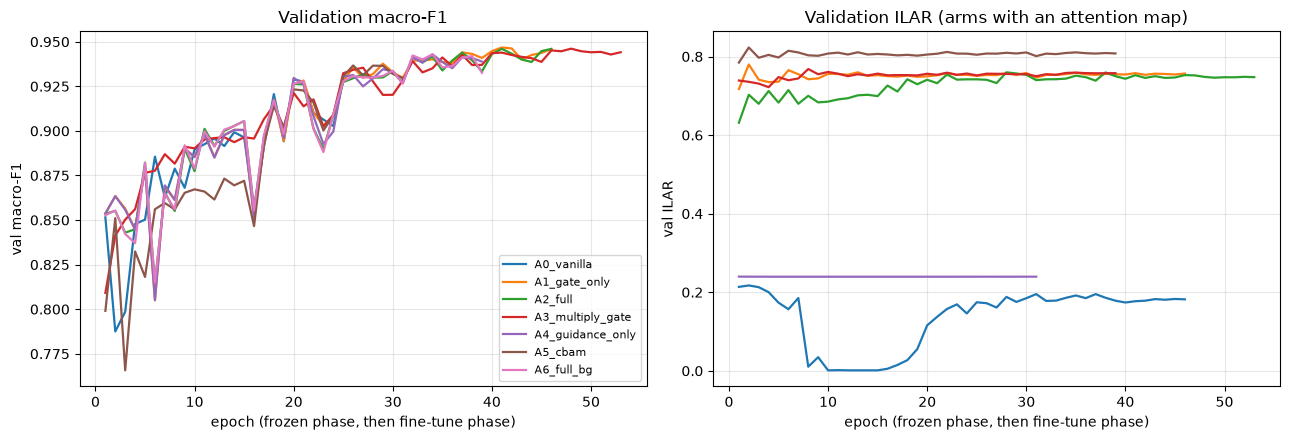

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name in ARM_ORDER:
    h1 = load_json(ARMS_ROOT / name / "phase1_frozen_history.json")
    h2 = load_json(ARMS_ROOT / name / "phase2_finetune_history.json")
    hist = h1 + h2
    x = np.arange(1, len(hist) + 1)

    axes[0].plot(x, [r["val_macro_f1"] for r in hist], label=name, linewidth=1.6)

    ilar = [r["val_ilar"] if r["val_ilar"] is not None else np.nan for r in hist]
    if not np.all(np.isnan(ilar)):                      # A0 has no attention map
        axes[1].plot(x, ilar, label=name, linewidth=1.6)

axes[0].set_xlabel("epoch (frozen phase, then fine-tune phase)")
axes[0].set_ylabel("val macro-F1")
axes[0].set_title("Validation macro-F1")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_xlabel("epoch (frozen phase, then fine-tune phase)")
axes[1].set_ylabel("val ILAR")
axes[1].set_title("Validation ILAR (arms with an attention map)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Test macro-F1 with confidence intervals, and F1 against localisation

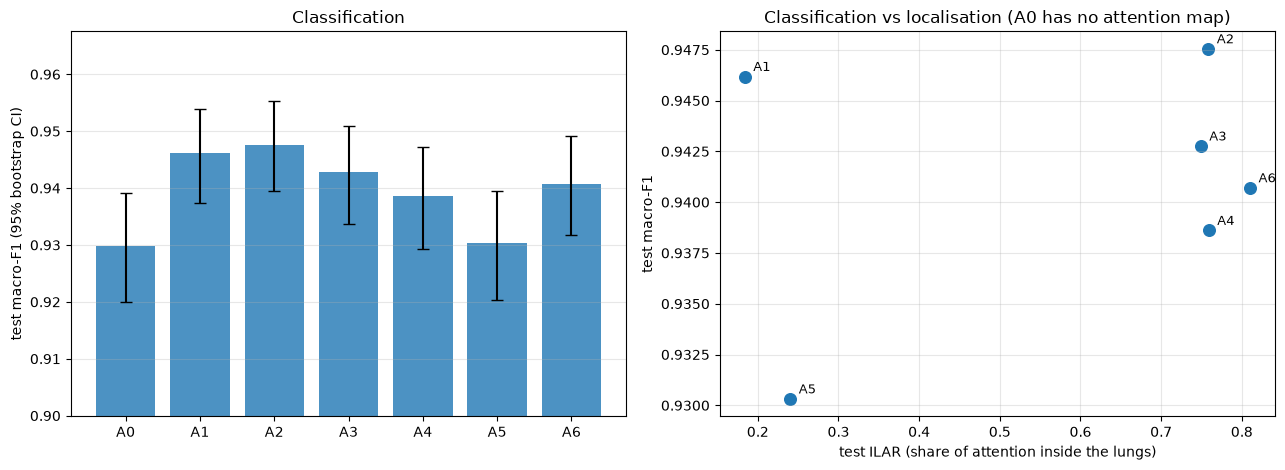

In [103]:
summary = pd.read_csv(ARMS_ROOT / "seven_arm_summary.csv").set_index("arm").loc[ARM_ORDER]
ci_idx = ci_df.set_index("arm").loc[ARM_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

f1 = ci_idx["test_macro_f1"].values
err = np.vstack([f1 - ci_idx["macro_f1_ci_low"].values, ci_idx["macro_f1_ci_high"].values - f1])
axes[0].bar(range(len(ARM_ORDER)), f1, yerr=err, capsize=4, color="tab:blue", alpha=0.8)
axes[0].set_xticks(range(len(ARM_ORDER)))
axes[0].set_xticklabels([n.split("_")[0] for n in ARM_ORDER])
axes[0].set_ylim(max(0.0, f1.min() - 0.03), min(1.0, f1.max() + 0.02))
axes[0].set_ylabel("test macro-F1 (95% bootstrap CI)")
axes[0].set_title("Classification")
axes[0].grid(axis="y", alpha=0.3)

has_att = summary["test_ilar"].notna()
axes[1].scatter(summary.loc[has_att, "test_ilar"], summary.loc[has_att, "test_macro_f1"], s=70)
for n in summary.index[has_att]:
    axes[1].annotate(n.split("_")[0], (summary.loc[n, "test_ilar"], summary.loc[n, "test_macro_f1"]),
                     textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[1].set_xlabel("test ILAR (share of attention inside the lungs)")
axes[1].set_ylabel("test macro-F1")
axes[1].set_title("Classification vs localisation (A0 has no attention map)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "f1_and_localisation.png", dpi=150, bbox_inches="tight")
plt.show()

## Confusion matrices and per-class F1

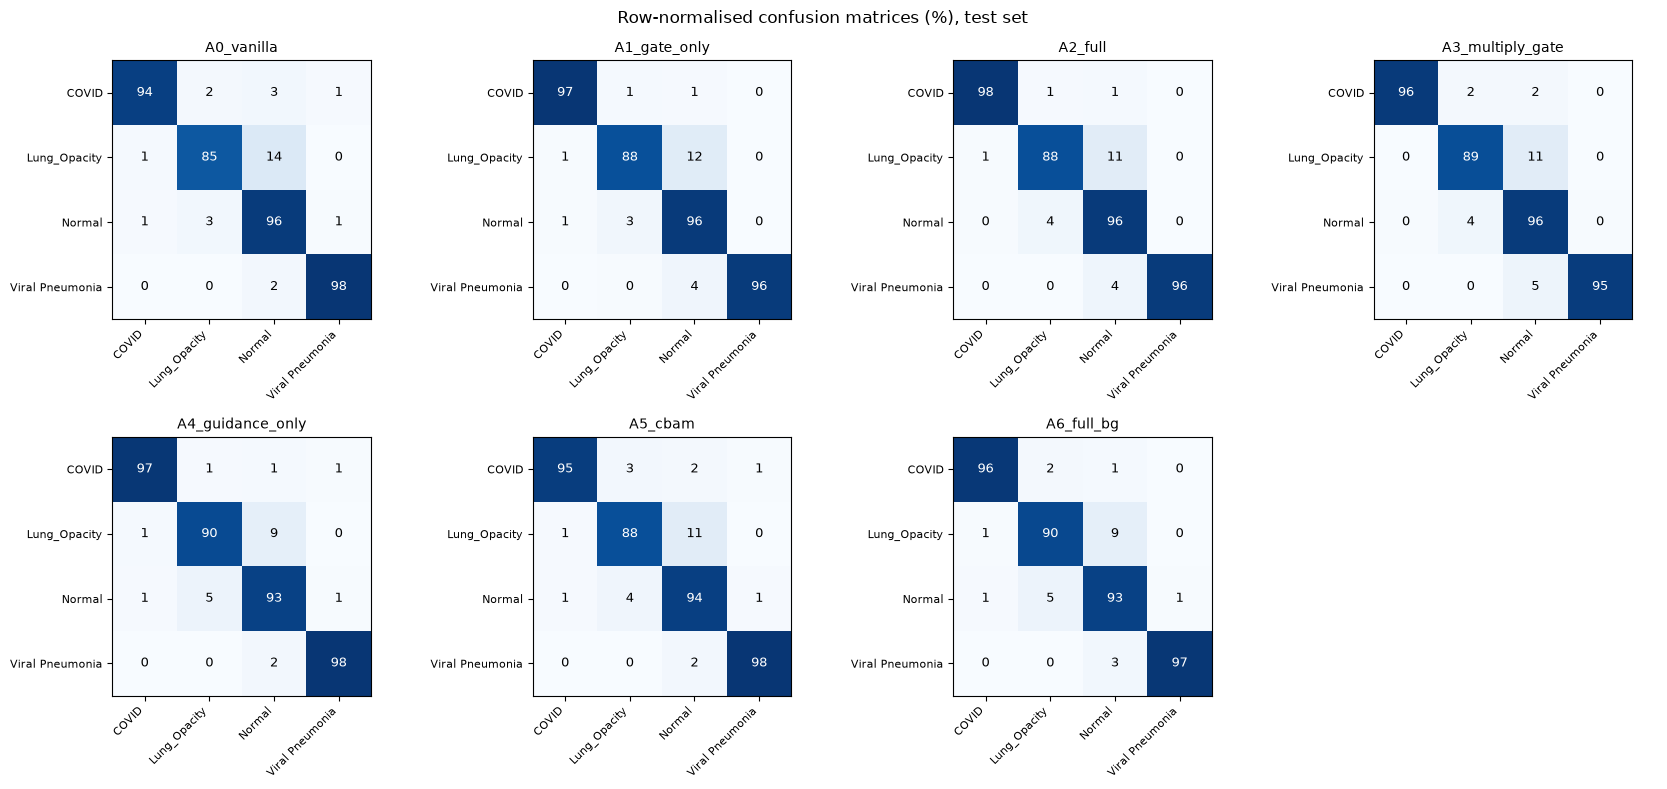

Saved: runs\vit_base_lung_attention\evaluation\per_class_f1.csv


,arm,COVID,Lung_Opacity,Normal,Viral Pneumonia,macro_avg
0,A0_vanilla,0.9480,0.8857,0.9318,0.9540,0.9299
1,A1_gate_only,0.9733,0.9039,0.9426,0.9650,0.9462
2,A2_full,0.9751,0.9037,0.9415,0.9698,0.9475
3,A3_multiply_gate,0.9711,0.9049,0.9399,0.9552,0.9428
4,A4_guidance_only,0.9625,0.8990,0.9343,0.9586,0.9386
5,A5_cbam,0.9519,0.8966,0.9325,0.9403,0.9303
6,A6_full_bg,0.9658,0.9012,0.9350,0.9608,0.9407


In [104]:
class_names = list(base_dataset.classes)

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.ravel()

pc_rows = []
for ax, name in zip(axes, ARM_ORDER):
    cm = pd.read_csv(ARMS_ROOT / name / "confusion_matrix_finetuned.csv", index_col=0).values
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    ax.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm_norm[i, j]*100:.0f}", ha="center", va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=9)

    rep = load_json(ARMS_ROOT / name / "test_results_finetuned.json")["classification_report"]
    pc_rows.append({"arm": name, **{c: rep[c]["f1-score"] for c in class_names},
                    "macro_avg": rep["macro avg"]["f1-score"]})

for ax in axes[len(ARM_ORDER):]:
    ax.axis("off")

fig.suptitle("Row-normalised confusion matrices (%), test set", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

per_class_df = pd.DataFrame(pc_rows)
per_class_df.to_csv(EVAL_DIR / "per_class_f1.csv", index=False)
print("Saved:", EVAL_DIR / "per_class_f1.csv")
per_class_df.round(4)